In [2]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

from pathlib import Path
analy_script_path = Path.cwd().parent.parent.parent / 'analysis'
if str(analy_script_path) not in sys.path:
    sys.path.append(str(analy_script_path))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import corner

from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc
import post_anal as pa



from aquarel import load_theme
theme_notused = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme = (
        load_theme("scientific")
        .set_font(family="serif", serif=["cmr10"]) # useless since text.usetex is set to True
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="xx-large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
            "axes.formatter.use_mathtext": "True",
            'mathtext.fontset':'cm',
            "text.usetex":"True"
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20
solo_fontsize = 16
cols = ['#ffac00', '#4e3fee', '#ea1900', '#8EC7D2', "#DC267F"]

plot_dir = "/home/sam/thesis/writingII/images/"

In [3]:
indices = list(range(0, 20000, 200))
if indices[-1] != 19999:
    indices.append(19999)


In [4]:
eos_se, mr_se = pa.load_eos_data('SE_10ns_11') # regenerated SE1
eos_se2, mr_se2 = pa.load_eos_data('SE_10ns_2')
eos_se3, mr_se3 = pa.load_eos_data('SE_10ns_3')
eos_se4, mr_se4 = pa.load_eos_data('SE_10ns_4')
eos_se5, mr_se5 = pa.load_eos_data('SE_10ns_5')
eos_sevi, mr_sevi = pa.load_eos_data('SE_10ns_VI')
eos_ge, mr_ge = pa.load_eos_data('GE_10ns_1')
eos_ge2, mr_ge2 = pa.load_eos_data('GE_10ns_2')
eos_m32, mr_m32 = pa.load_eos_data('M32_10ns_1')
eos_m322, mr_m322 = pa.load_eos_data('M32_10ns_2')
eos_m323, mr_m323 = pa.load_eos_data('M32_10ns_3')
eos_m52, mr_m52 = pa.load_eos_data('M52_10ns_1')
eos_m522, mr_m522 = pa.load_eos_data('M52_10ns_2')
eos_m523, mr_m523 = pa.load_eos_data('M52_10ns_3')
eos_rq, mr_rq = pa.load_eos_data('RQ_10ns_1')
eos_rq2, mr_rq2 = pa.load_eos_data('RQ_10ns_2')
eos_rq3, mr_rq3 = pa.load_eos_data('RQ_10ns_3')

In [5]:
n_ceft, p_ceft_avg, p_ceft_upper, p_ceft_lower = anal.get_ceft("pressure")
n_ceft, cs2ceft_avg, cs2ceft_upper, cs2ceft_lower = anal.get_ceft_cs2()
n_crust, p_crust_avg, p_crust_upper, p_crust_lower = anal.get_crust("pressure")
n_crust, cs2crust_avg, cs2crust_upper, cs2crust_lower = anal.get_crust("cs2")

cs2_data = np.concatenate((cs2crust_avg[:-2], cs2ceft_avg))
cs2_upper = np.concatenate((cs2crust_upper[:-2], cs2ceft_upper))
cs2_lower = np.concatenate((cs2crust_lower[:-2], cs2ceft_lower))

p_data = np.concatenate((p_crust_avg[:-2], p_ceft_avg))
p_upper = np.concatenate((p_crust_upper[:-2], p_ceft_upper))
p_lower = np.concatenate((p_crust_lower[:-2], p_ceft_lower))

n_data = np.concatenate((n_crust[:-2], n_ceft))

n = anal.get_n_test(n_end=10, numpoints=200)

In [15]:
def nbreak_plot(folder_names, colours, labs = None, plot_prior=False, legend_fontsize=14, axis_fontsize=14):

    if labs is None:
        labs = [None] * len(folder_names)
    if plot_prior:
        unif_nbreak_sams = np.random.uniform(low=1.0, high=2.0, size=20000)
        plt.hist(unif_nbreak_sams, bins=20, density=True, label='Uniform Hyperprior', color='black', histtype='step')
    for i, folder in enumerate(folder_names):
        nbreak = np.load(f"/home/sam/thesis/code/results/eos_samples/{folder}/{folder}_nceft_end.npy")
        plt.hist(nbreak, bins=20, density=True, label=labs[i], color=colours[i], histtype='step')
    
    plt.ylabel("Density", fontsize=axis_fontsize)
    plt.xlabel("$n_{\mathrm{break}}$ in $n_{\mathrm{sat}}$", fontsize=axis_fontsize)

In [13]:
def n_14m(eos: np.array, mr: np.array,
          n: np.array= None, m_target: float=1.4) -> np.array:
    """
    Returns the central density n_central for a given target mass m_target (default 1.4 Msol) for each EOS sample in the provided eos and mr arrays.

    Parameters:
    eos (np.array): The equation of state data.
    mr (np.array): The mass-radius data.
    n (np.array, optional): The density grid. Defaults to a grid used to build GP samples.
    m_target (float, optional): The target mass. Defaults to 1.4 Msol.

    Returns:
    np.array: The central density for each EOS sample.
    """
    if n is None:
        n = anal.get_n_test(10, 200)

    n14m = np.zeros(mr.shape[1])

    for i in range(mr.shape[1]):
        n_central = np.interp(mr[-1, i, :], eos[1, i, :], n)

        n14m[i] = np.interp(m_target, mr[1, i, :], n_central, left=np.nan, right=np.nan)

    return n14m

# square exponential

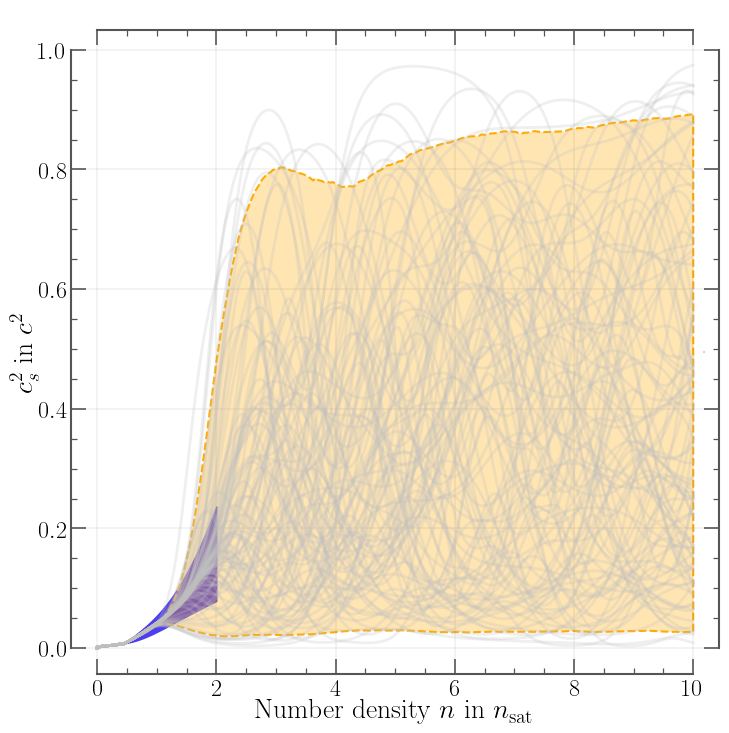

In [17]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.fill_between(n_data, cs2_lower, cs2_upper, color='#4e3fee', alpha=1)

pa.plot_eos_comparisons([eos_se], ax1=None, ax2=ax1, 
                        mr_list=[mr_se], 
                        labels=None, colours=["#ffac00"], plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0)

for i in indices:
    ax1.plot(n, eos_se[2, i, :], color='silver', alpha=0.25)

ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_cs2_prior.png", dpi=300)
plt.show()

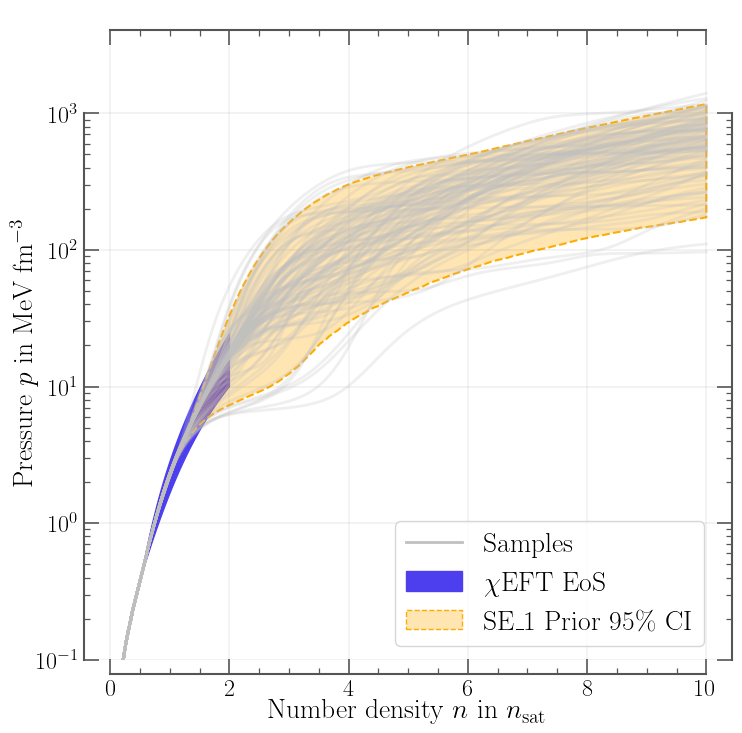

In [5]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color='silver', alpha=1, label='Samples')
plt.fill_between(n_data, p_lower, p_upper, color='#4e3fee', alpha=1, label=r'$\chi$EFT EoS')

pa.plot_eos_comparisons([eos_se], ax1=ax1, 
                        mr_list=[mr_se], 
                        labels=['SE_1 Prior 95\% CI'], colours=["#ffac00"], plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize)

for i in indices:
    ax1.plot(n, eos_se[1, i, :], color='silver', alpha=0.25)

plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_p_prior.png", dpi=300)
plt.show()

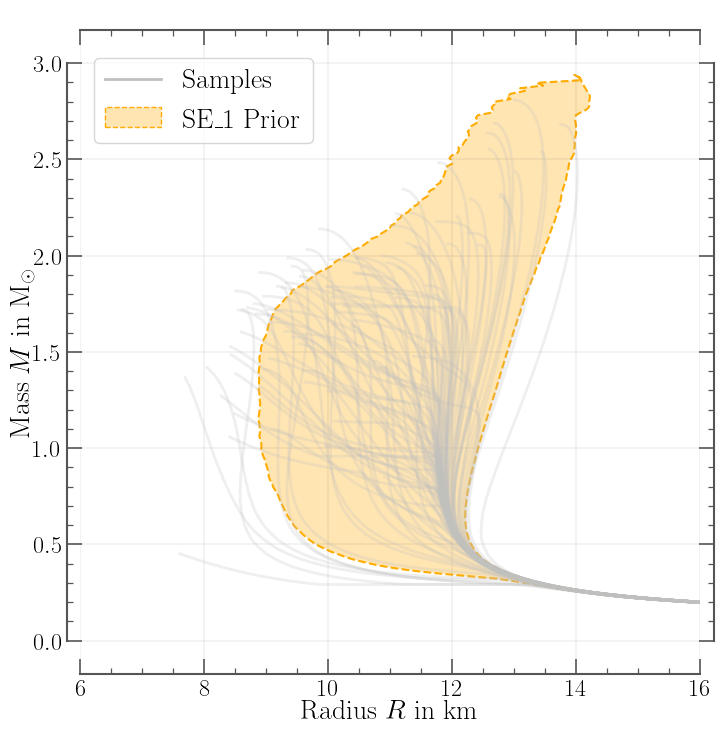

In [6]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


plt.plot([], [], color='silver', alpha=1, label='Samples')

for i in indices:
    plt.plot(mr_se[0, i, :], mr_se[1, i, :], color='silver', alpha=0.25)

pa.plot_eos_comparisons([eos_se], ax3=ax1, 
                        mr_list=[mr_se], 
                        labels=['SE_1 Prior'], colours=["#ffac00"], plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize)

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_mr_prior.png", dpi=300)
plt.show()

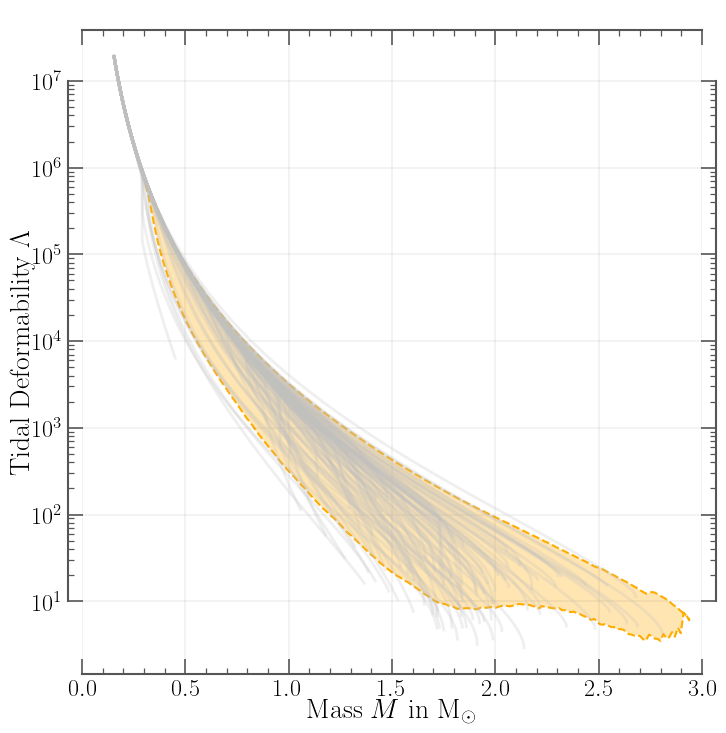

In [20]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color='silver', alpha=1, label='Samples')

for i in indices:
    ax1.plot(mr_se[1, i, :], mr_se[2, i, :], color='silver', alpha=0.25)

pa.plot_eos_comparisons([eos_se], ax4=ax1, 
                        mr_list=[mr_se], 
                        labels=['SE1 Prior'], colours=["#ffac00"], plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0)

ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_mt_prior.png", dpi=300)
plt.show()

## pqcd + cheft vs cheft alone

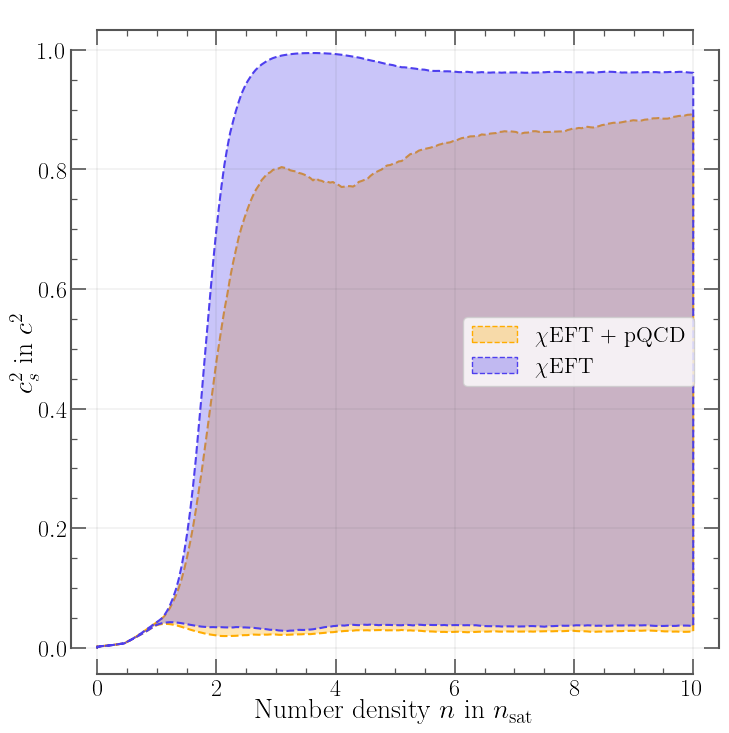

In [12]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se, eos_sevi], ax1=None, ax2=ax1, 
                        mr_list=[mr_se, mr_sevi], 
                        labels=['$\chi$EFT + pQCD', '$\chi$EFT'], 
                        colours=cols, plot_alone="cs2",
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=solo_fontsize)
ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_pqcd_ceft.png", dpi=300)
plt.show()

## nbreak

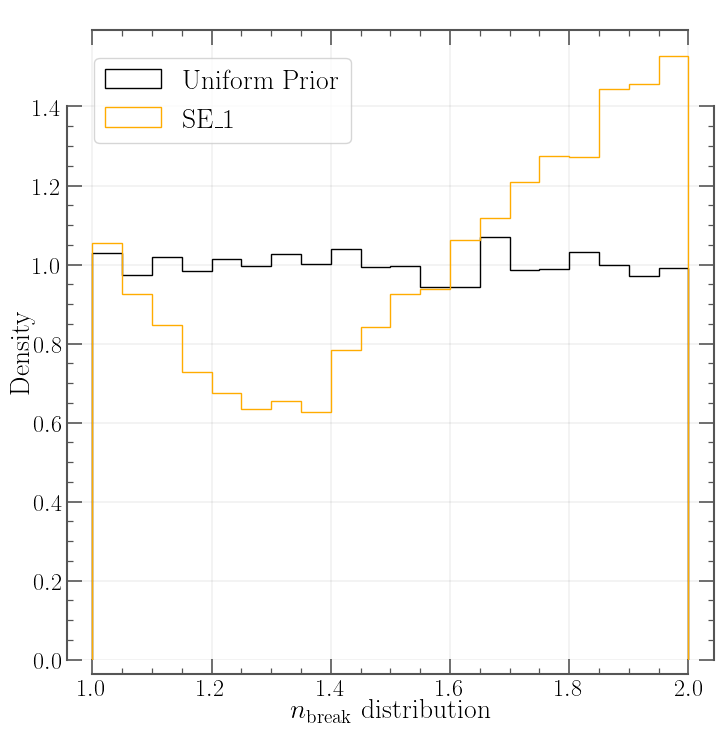

In [132]:
plt.figure(figsize=(8, 8))
nbreak_plot(["SE_10ns_11"], cols,
            plot_prior=True, 
            labs=["SE_1", "RQ_1", "GE_1", "M32_1", "M52_1"],
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.show()

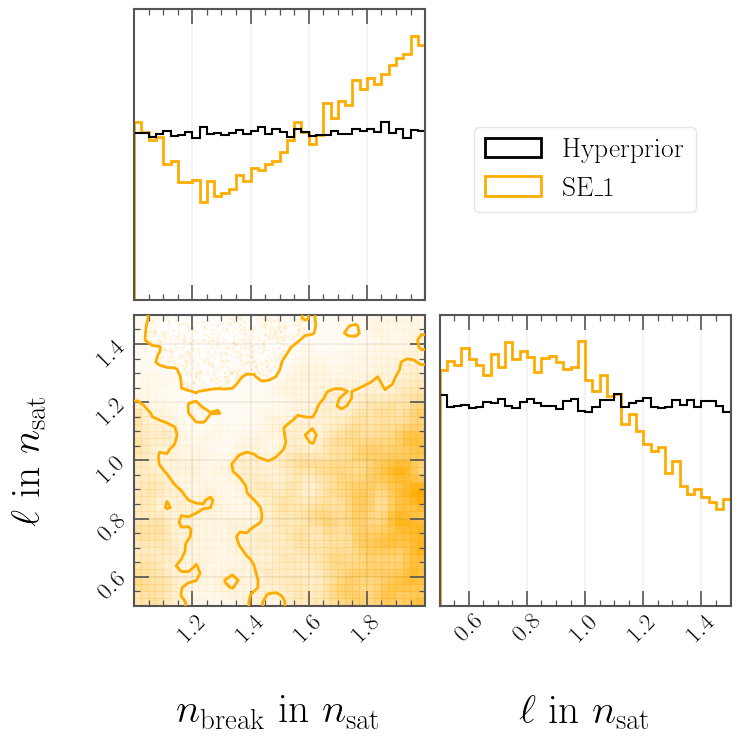

In [63]:
fol = "SE_10ns_1V"
nbreak = np.load(f"/home/sam/thesis/code/results/eos_samples/{fol}/{fol}_nceft_end.npy")
l_hat = np.load(f"/home/sam/thesis/code/results/eos_samples/{fol}/{fol}_lengthscale.npy")

nbreak_prior = np.random.uniform(low=1.0, high=2.0, size=100000)
l_hat_prior = np.random.uniform(low=0.5, high=1.5, size=100000)

fig = corner.corner(np.vstack((nbreak, l_hat)).T, 
              labels=[r"$n_{\mathrm{break}}$ in $n_{\mathrm{sat}}$", r"$\ell$ in $n_{\mathrm{sat}}$"],
              bins=40,
              smooth=True,
              levels=[0.68, 0.95],
              color=cols[0],
              hist_kwargs={"density": True, "fill": False, "linewidth": 2, "histtype": "step"},
              plot_density=True,
              plot_datapoints=True,
              fill_contours=False,
              contourf_kwargs=dict(zorder=2, alpha=[0.0, 0.4, 0.8]),
              contour_kwargs=dict(zorder=3),
              fig=plt.figure(figsize=(8, 8)),   
              title_kwargs={"fontsize": 20},
              title_fmt=".3f",
              axes_kwargs={"fontsize": 30}, 
              label_kwargs=dict(fontsize=30),
              )


xmin1 = min(nbreak.min(), nbreak_prior.min())
xmax1 = max(nbreak.max(), nbreak_prior.max())
xmin2 = min(l_hat.min(), l_hat_prior.min())
xmax2 = max(l_hat.max(), l_hat_prior.max())
ranges = [(xmin1, xmax1), (xmin2, xmax2)]

axes = np.array(fig.axes).reshape((2, 2))

prior_samples = np.vstack((nbreak_prior, l_hat_prior)).T

for i in range(2):
    ax = axes[i, i]
    bins = np.linspace(ranges[i][0], ranges[i][1], 41)  # 40 bins
    ax.hist(
        prior_samples[:, i],
        bins=bins,
        density=True,
        histtype='step',
        color='black',
        linewidth=1.5,
    )
handles2 = [Patch(edgecolor='black', lw=2, label='Hyperprior', fill=False), 
            Patch(color=cols[0], lw=2, label='SE\_1', fill=False),
            ]
plt.legend(handles=handles2, fontsize=big_fontsize, loc='center', bbox_to_anchor=(0.5, 1.5), fancybox=True, framealpha=0.5)
theme.apply()
plt.savefig(plot_dir + "nbreak_lengthscale.png", dpi=300)
plt.show()

# diff kerns

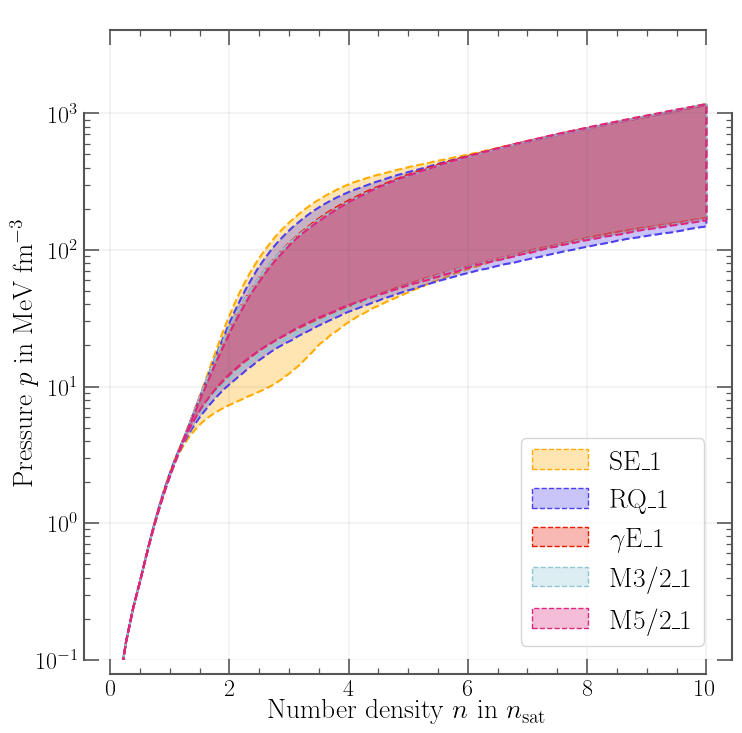

In [33]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_rq, eos_ge, eos_m32, eos_m52], 
                        ax1, 
                        mr_list=[mr_se, mr_rq, mr_ge, mr_m32, mr_m52], 
                        labels=['SE_1', 'RQ_1', '$\gamma$E_1', 'M3/2_1', 'M5/2_1'], 
                        colours=cols,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
#ax1.set_ylim(0.1,1000)
#ax1.set_yscale('linear')
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kern_p_prior.png", dpi=300)
plt.show()

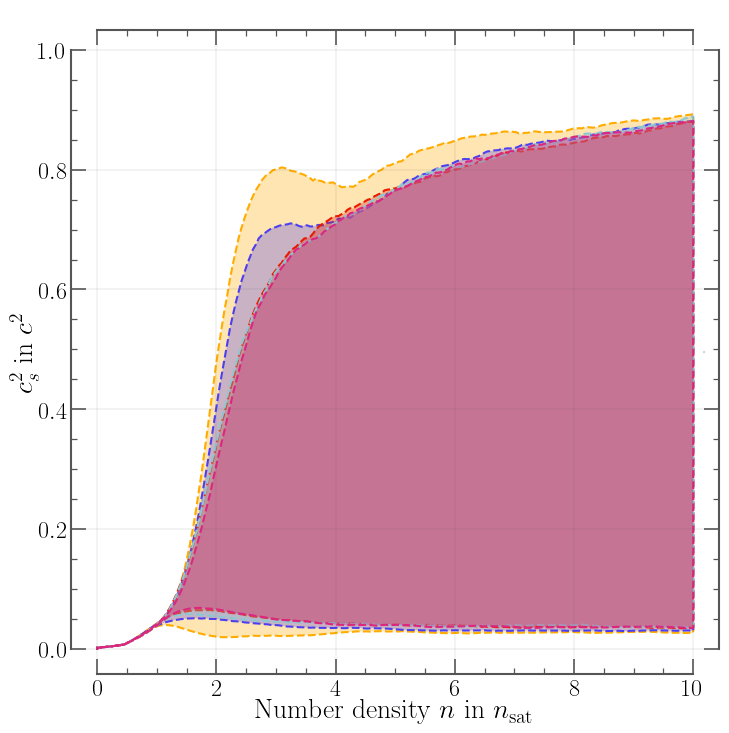

In [45]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_rq, eos_ge, eos_m32, eos_m52], ax1=None, ax2=ax1, 
                        mr_list=[mr_se, mr_rq, mr_ge, mr_m32, mr_m52], 
                        labels=['SE', 'RQ', 'GE', 'M3/2', 'M5/2'], 
                        colours=cols, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kern_cs2_prior.png", dpi=300)
plt.show()

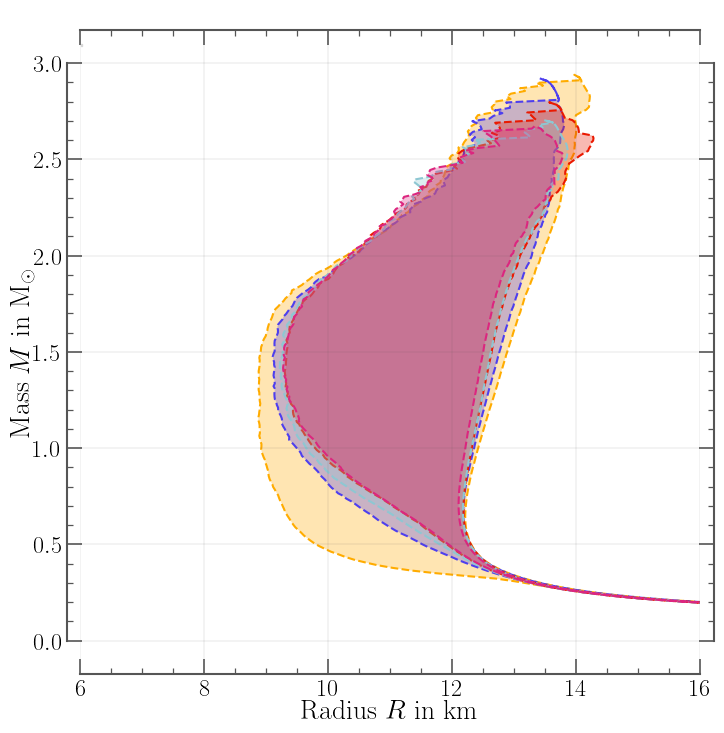

In [34]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
#ax1.fill_between(n_ceft, p_ceft_lower, p_ceft_upper, label="$\chi$EFT")
pa.plot_eos_comparisons([eos_se, eos_rq, eos_ge, eos_m32, eos_m52], ax1=None, ax3=ax1, 
                        mr_list=[mr_se, mr_rq, mr_ge, mr_m32, mr_m52], 
                        labels=['SE', 'RQ', 'GE', 'M3/2', 'M5/2'], 
                        colours=cols, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kern_mr_prior.png", dpi=300)
plt.show()

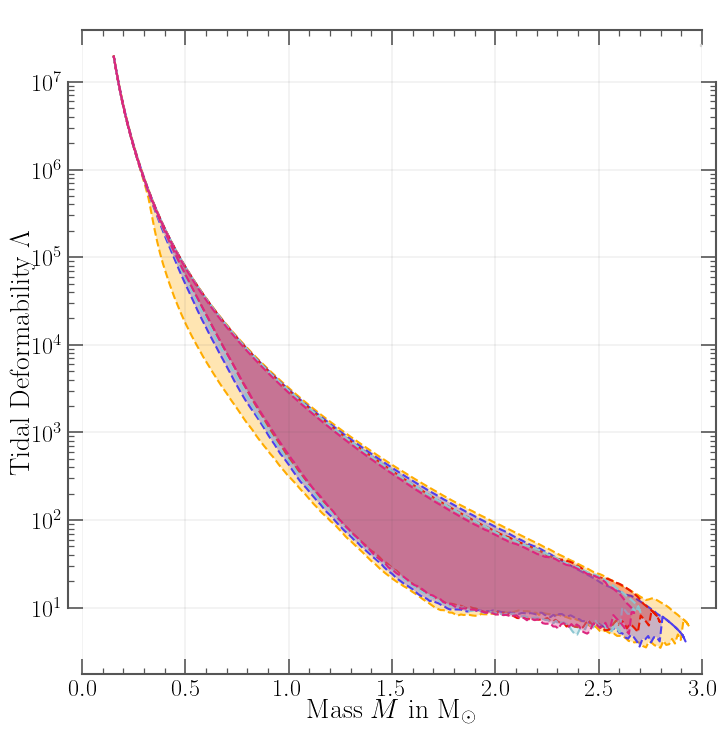

In [21]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_rq, eos_ge, eos_m32, eos_m52], ax1=None, ax4=ax1, 
                        mr_list=[mr_se, mr_rq, mr_ge, mr_m32, mr_m52], 
                        labels=['SE', 'RQ', 'GE', 'M3/2', 'M5/2'], 
                        colours=cols, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
ax1.set_xlim(0, 3)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kern_tide_prior.png", dpi=300)
plt.show()

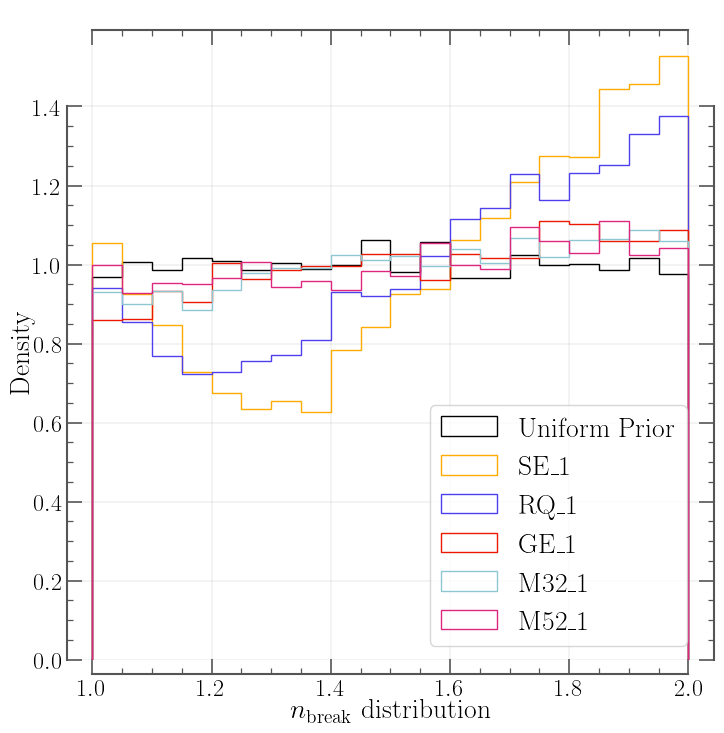

In [131]:
plt.figure(figsize=(8, 8))
nbreak_plot(["SE_10ns_11", "RQ_10ns_1", "GE_10ns_1", "M32_10ns_1", "M52_10ns_1"], cols,
            plot_prior=True, 
            labs=["SE_1", "RQ_1", "GE_1", "M32_1", "M52_1"],
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.show()

## SE vs all samples

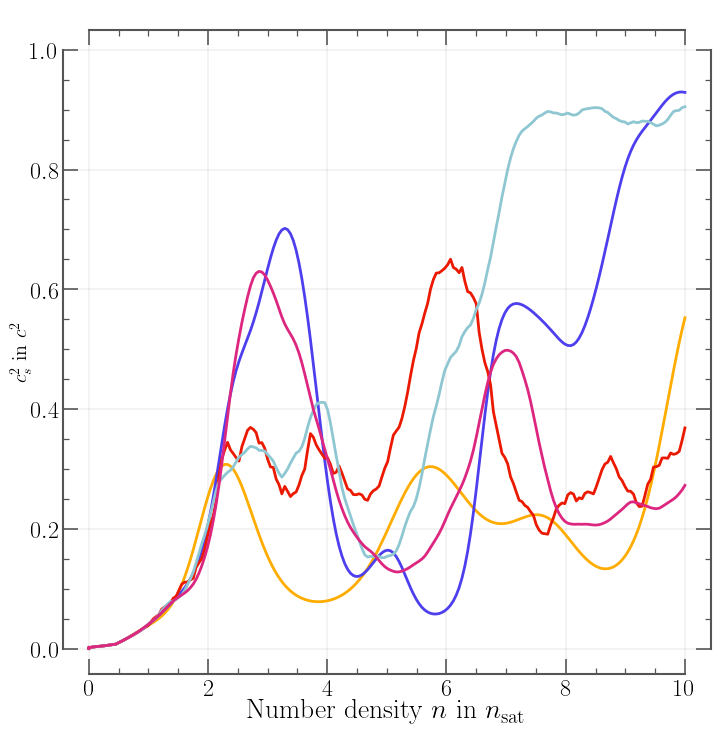

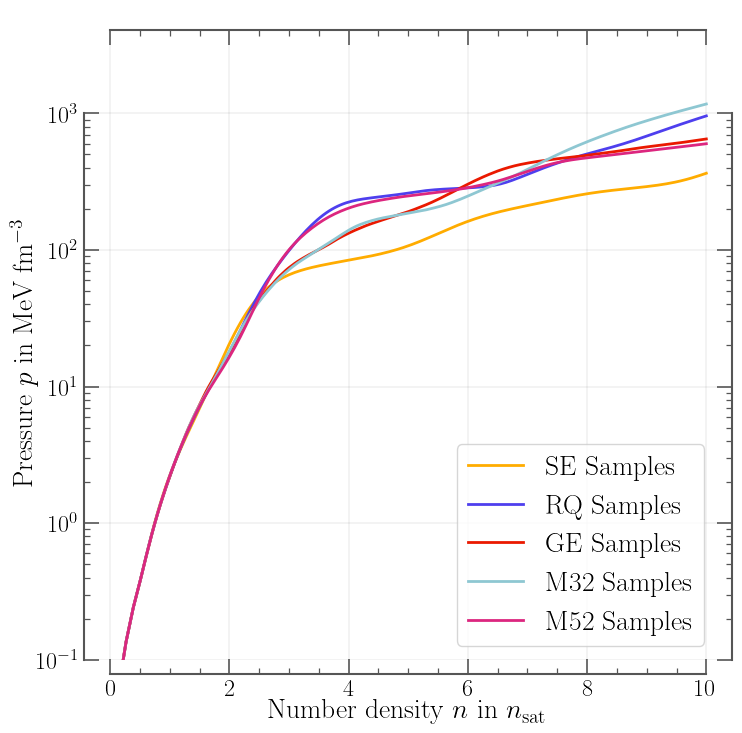

In [28]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

inds = np.random.choice(range(20000), size=1, replace=False)

ax1.plot([], [], color=cols[0], alpha=1, label='SE Samples')
ax1.plot([], [], color=cols[1], alpha=1, label='RQ Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='GE Samples')
ax1.plot([], [], color=cols[3], alpha=1, label='M32 Samples')
ax1.plot([], [], color=cols[4], alpha=1, label='M52 Samples')

for i in inds:
    ax1.plot(n, eos_se[2, i, :], color=cols[0], alpha=1, linewidth=2)
    ax1.plot(n, eos_rq[2, i, :], color=cols[1], alpha=1, linewidth=2)
    ax1.plot(n, eos_ge[2, i, :], color=cols[2], alpha=1, linewidth=2)
    ax1.plot(n, eos_m32[2, i, :], color=cols[3], alpha=1, linewidth=2)
    ax1.plot(n, eos_m52[2, i, :], color=cols[4], alpha=1, linewidth=2)

ax1.set_ylabel(r"$c_s^2$ in $c^2$")
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_ge_cs2.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color=cols[0], alpha=1, label='SE Samples')
ax1.plot([], [], color=cols[1], alpha=1, label='RQ Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='GE Samples')
ax1.plot([], [], color=cols[3], alpha=1, label='M32 Samples')
ax1.plot([], [], color=cols[4], alpha=1, label='M52 Samples')

for i in inds:
    ax1.plot(n, eos_se[1, i, :], color=cols[0], alpha=1, linewidth=2)
    ax1.plot(n, eos_rq[1, i, :], color=cols[1], alpha=1, linewidth=2)
    ax1.plot(n, eos_ge[1, i, :], color=cols[2], alpha=1, linewidth=2)
    ax1.plot(n, eos_m32[1, i, :], color=cols[3], alpha=1, linewidth=2)
    ax1.plot(n, eos_m52[1, i, :], color=cols[4], alpha=1, linewidth=2)
    

ax1.set_ylabel(r"Pressure $p$ in MeV fm$^{-3}$", fontsize=big_fontsize)
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.legend(loc='lower right', fontsize=big_fontsize)
ax1.set_yscale('log')
ax1.set_ylim(0.1,)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_ge_p.png", dpi=300)
plt.show()

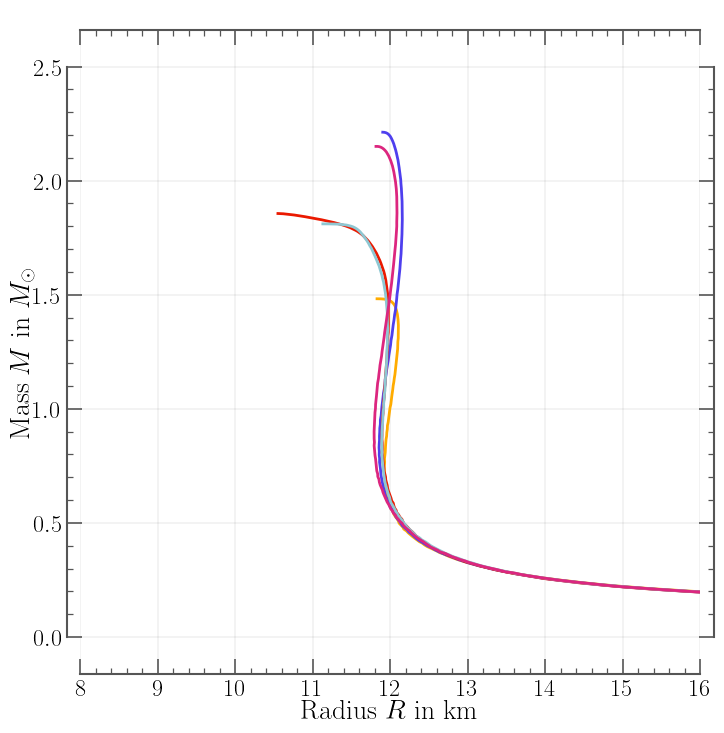

In [30]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color=cols[0], alpha=1, label='SE Samples')
ax1.plot([], [], color=cols[1], alpha=1, label='RQ Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='GE Samples')
ax1.plot([], [], color=cols[3], alpha=1, label='M32 Samples')
ax1.plot([], [], color=cols[4], alpha=1, label='M52 Samples')

for i in inds:
    ax1.plot(mr_se[0, i, :], mr_se[1, i, :], color=cols[0], alpha=1, linewidth=2)
    ax1.plot(mr_rq[0, i, :], mr_rq[1, i, :], color=cols[1], alpha=1, linewidth=2)
    ax1.plot(mr_ge[0, i, :], mr_ge[1, i, :], color=cols[2], alpha=1, linewidth=2)
    ax1.plot(mr_m32[0, i, :], mr_m32[1, i, :], color=cols[3], alpha=1, linewidth=2)
    ax1.plot(mr_m52[0, i, :], mr_m52[1, i, :], color=cols[4], alpha=1, linewidth=2)

ax1.set_xlabel(r"Radius $R$ in km", fontsize=big_fontsize)
ax1.set_ylabel(r"Mass $M$ in $M_\odot$", fontsize=big_fontsize)
ax1.set_ylim(-0.1,2.6)
ax1.set_xlim(8,16)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_ge_mr.png", dpi=300)
plt.show()

# Different limiting methods

## SE

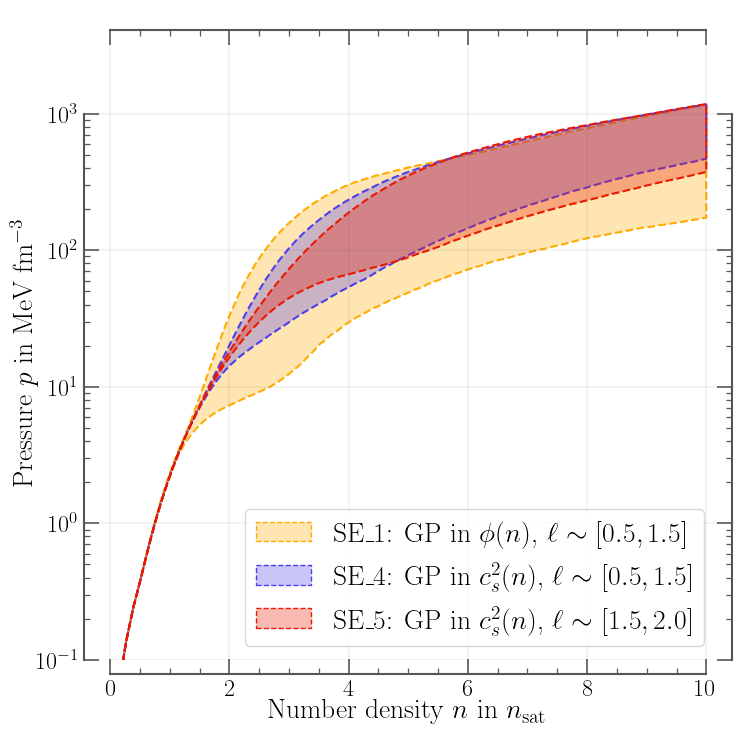

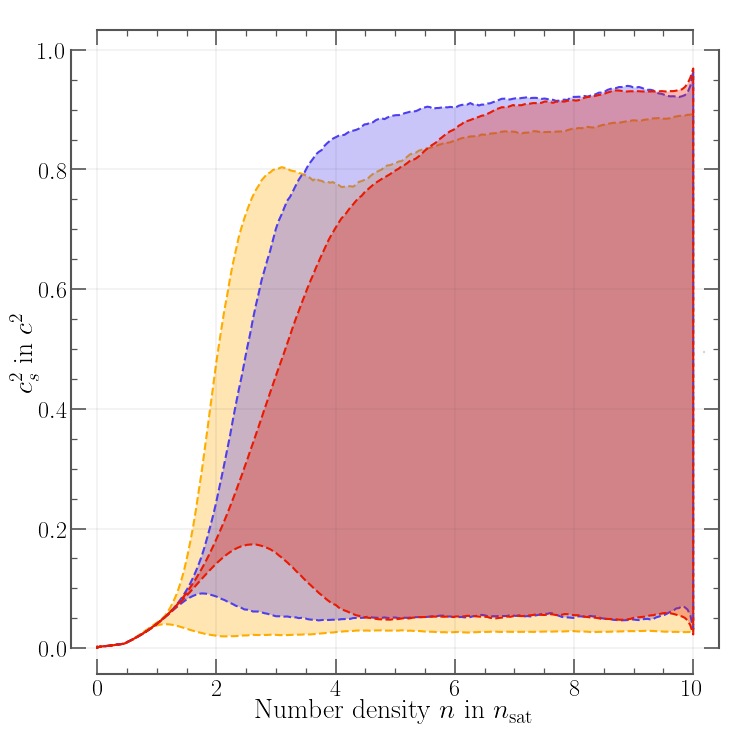

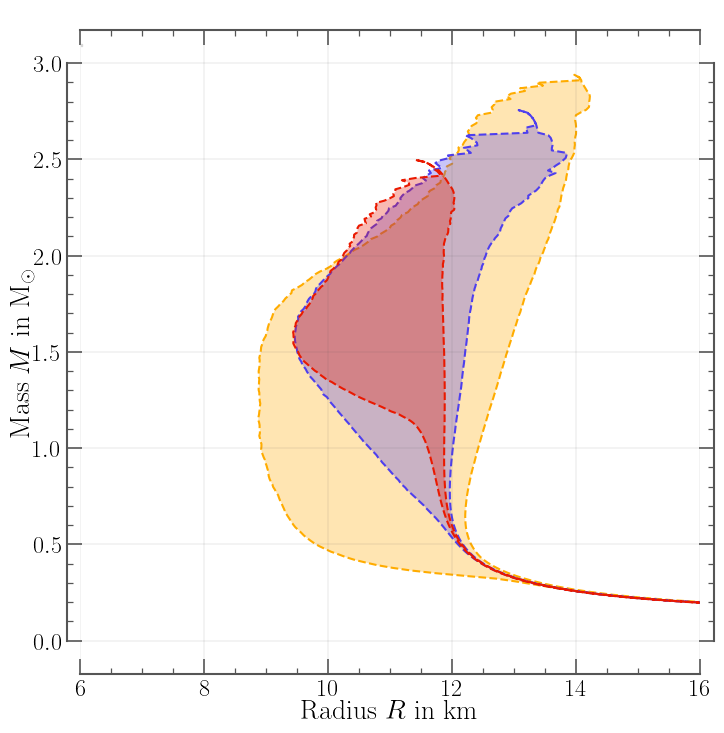

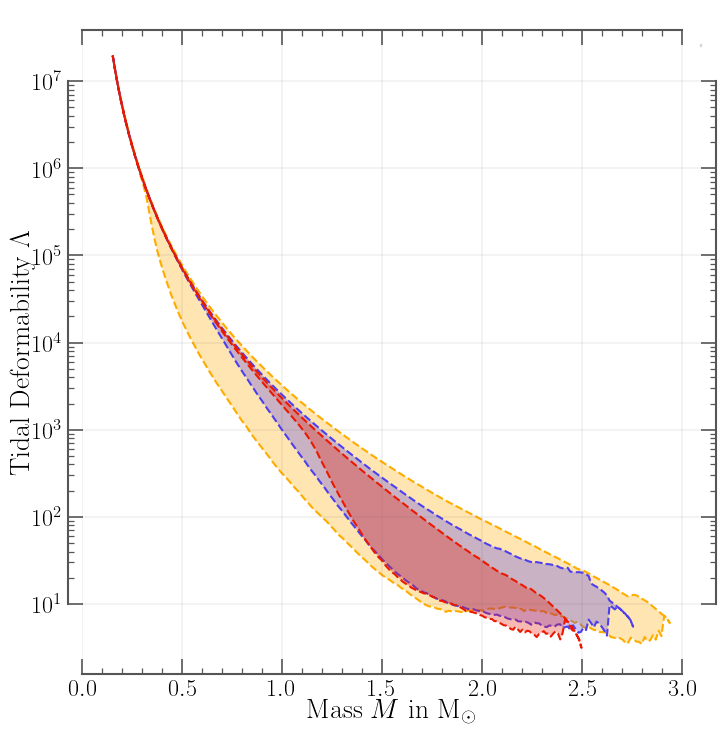

In [7]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se4, eos_se5], 
                        ax1, 
                        mr_list=[mr_se, mr_se4, mr_se5], 
                        labels=['SE_1: GP in $\phi(n)$, $\ell\sim[0.5,1.5]$', 'SE_4: GP in $c_s^2(n)$, $\ell\sim[0.5,1.5]$', 'SE_5: GP in $c_s^2(n)$, $\ell\sim[1.5,2.0]$'], 
                        colours=cols,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "limiting_se_p_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se4, eos_se5], ax1=None, ax2=ax1, 
                        mr_list=[mr_se, mr_se4, mr_se5], 
                        colours=cols, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "limiting_se_cs2_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se4, eos_se5], ax1=None, ax3=ax1, 
                        mr_list=[mr_se, mr_se4, mr_se5], 
                        colours=cols, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "limiting_se_mr_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se4, eos_se5], ax1=None, ax4=ax1, 
                        mr_list=[mr_se, mr_se4, mr_se5], 
                        colours=cols, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.xlim(0, 3.1)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "limiting_se_tide_prior.png", dpi=300)
plt.show()

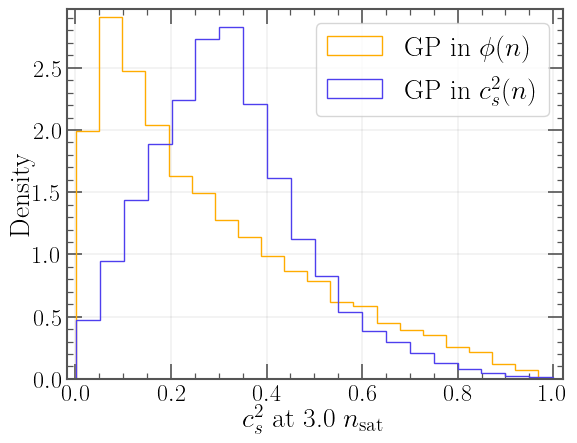

In [107]:
target_cs2 = 3.0
labs = ["GP in $\phi(n)$", "GP in $c_s^2(n)$"]
for i, (eos_i) in enumerate([eos_se, eos_se4]):
                data_0 = cs2_6ns(eos_i, cs2_target=target_cs2)

                plt.hist(data_0, bins=20, density=True, label=labs[i], color=cols[i], histtype='step') # the linestyle is the only element not repeated

plt.legend(fontsize=big_fontsize)
plt.xlabel(f"$c_s^2$ at {target_cs2} $n_{{\\mathrm{{sat}}}}$", fontsize=big_fontsize)
plt.ylabel("Density", fontsize=big_fontsize)
plt.show()

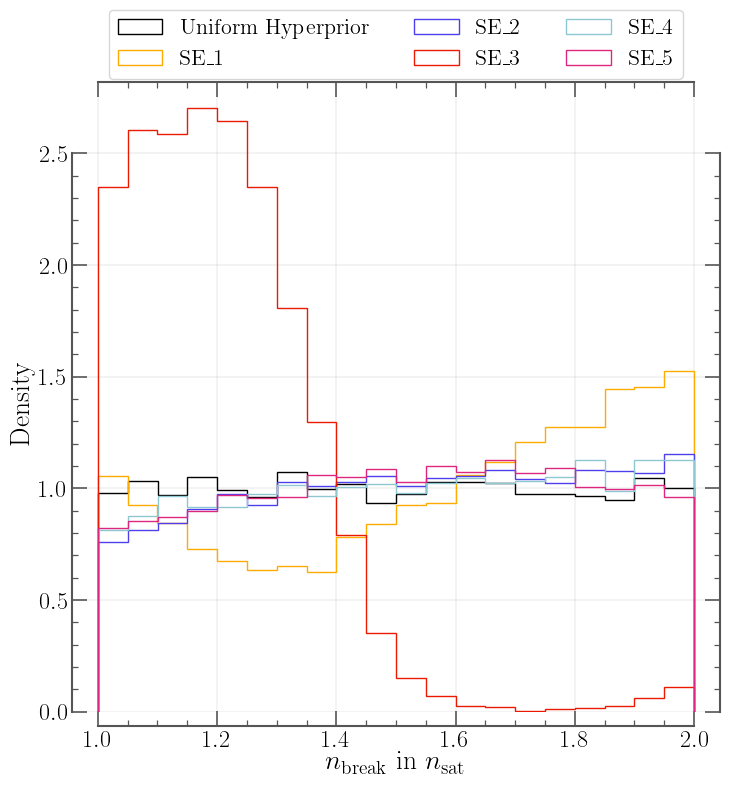

In [20]:
plt.figure(figsize=(8, 8))
nbreak_plot(['SE_10ns_1', 'SE_10ns_2', 'SE_10ns_3', 'SE_10ns_4', 'SE_10ns_5'], cols,
            plot_prior=True, 
            labs=["SE_1", "SE_2", "SE_3", "SE_4", "SE_5"],
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.legend(loc='lower center', fontsize=solo_fontsize, bbox_to_anchor=(0.5, 1.01),
          ncol=3)
plt.ylabel("Density", fontsize=big_fontsize, labelpad=3)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "se_nbreak_prior.png", dpi=300)
plt.show()

## cs2 kernels

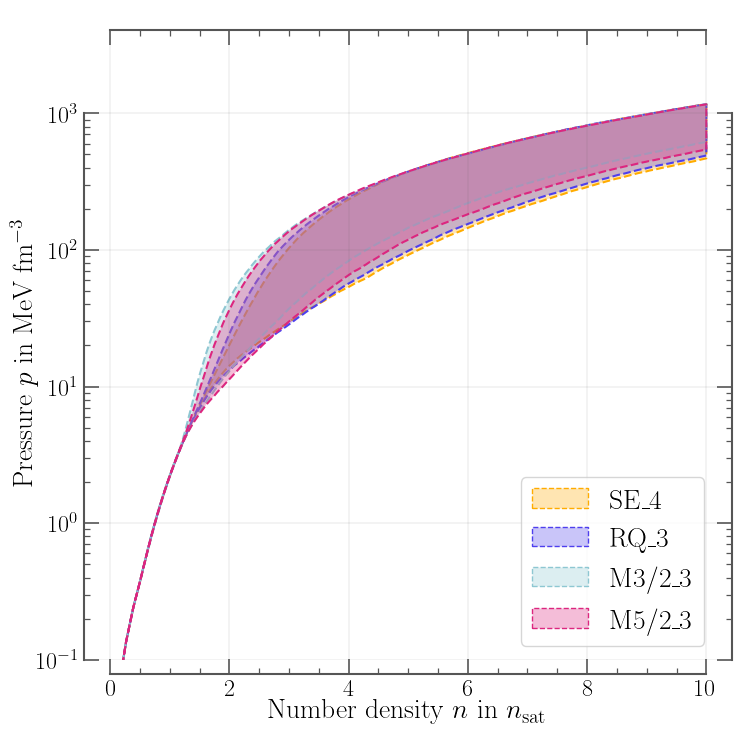

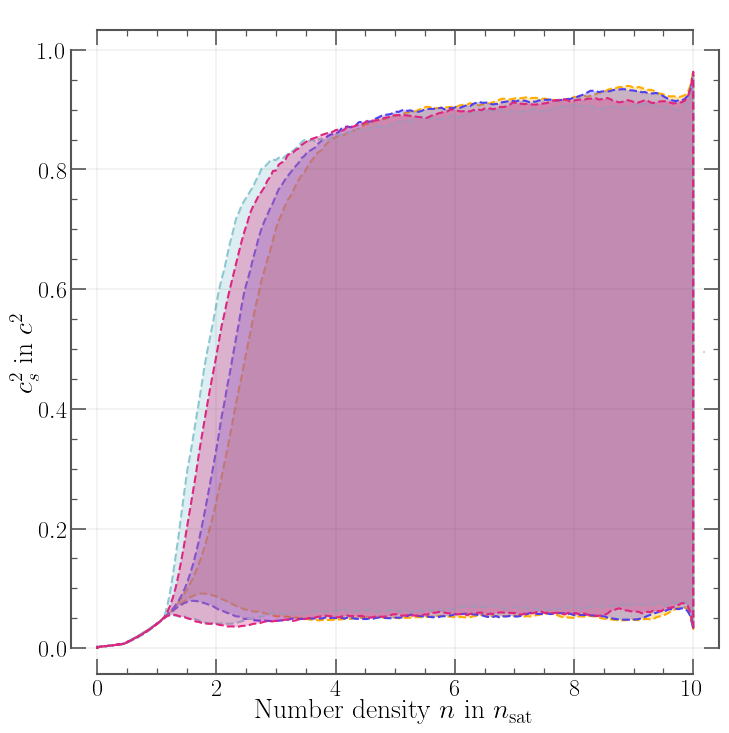

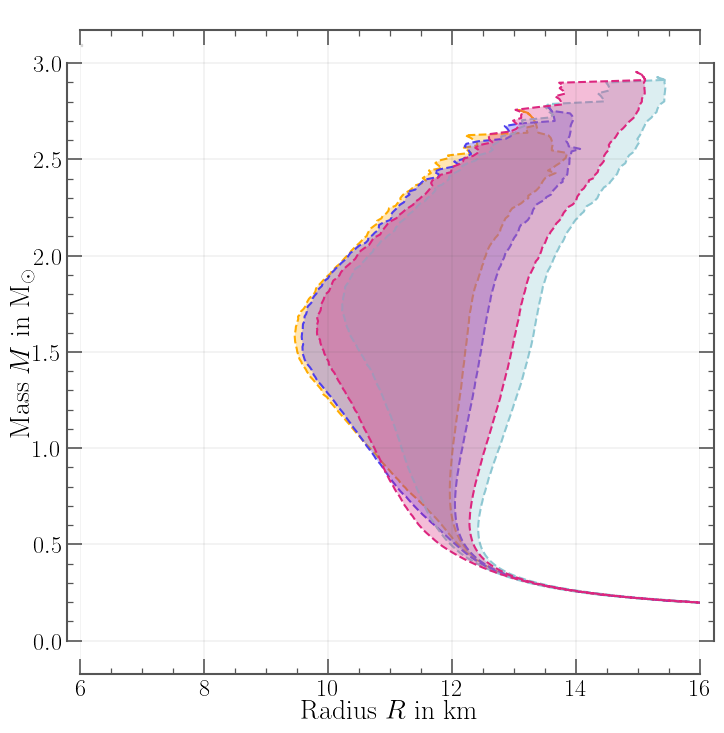

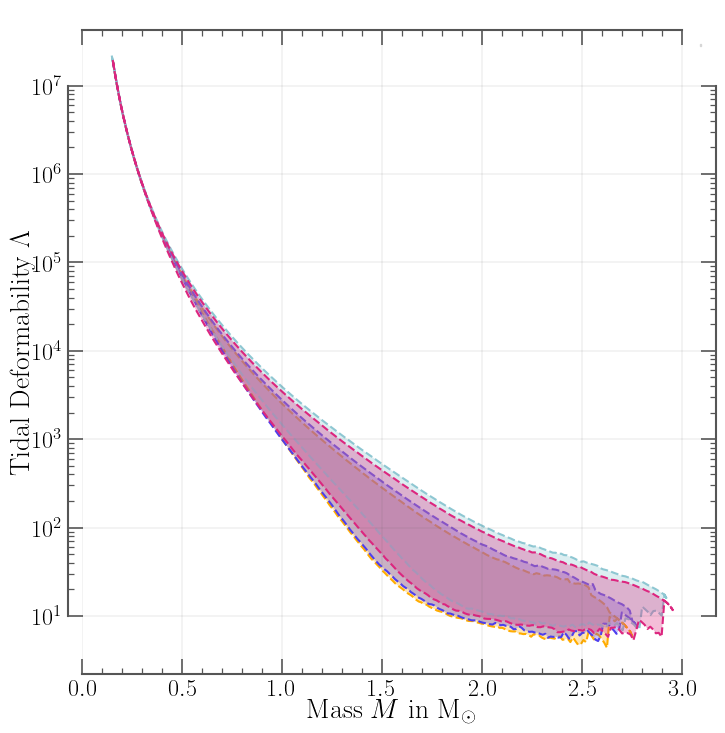

In [21]:
cols4 = cols[:2] + cols[3:]
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se4, eos_rq3, eos_m323, eos_m523], 
                        ax1, 
                        mr_list=[mr_se4, mr_rq3, mr_m323, mr_m523], 
                        labels=['SE_4', 'RQ_3', 'M3/2_3', 'M5/2_3'], 
                        colours=cols4,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "cs2_kernel_p_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se4, eos_rq3, eos_m323, eos_m523], ax1=None, ax2=ax1, 
                        mr_list=[mr_se4, mr_rq3, mr_m323, mr_m523], 
                        colours=cols4, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "cs2_kernel_cs2_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se4, eos_rq3, eos_m323, eos_m523], ax1=None, ax3=ax1, 
                        mr_list=[mr_se4, mr_rq3, mr_m323, mr_m523], 
                        colours=cols4, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "cs2_kernel_mr_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se4, eos_rq3, eos_m323, eos_m523], ax1=None, ax4=ax1, 
                        mr_list=[mr_se4, mr_rq3, mr_m323, mr_m523], 
                        colours=cols4, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.xlim(0, 3.1)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "cs2_kernel_tide_prior.png", dpi=300)
plt.show()

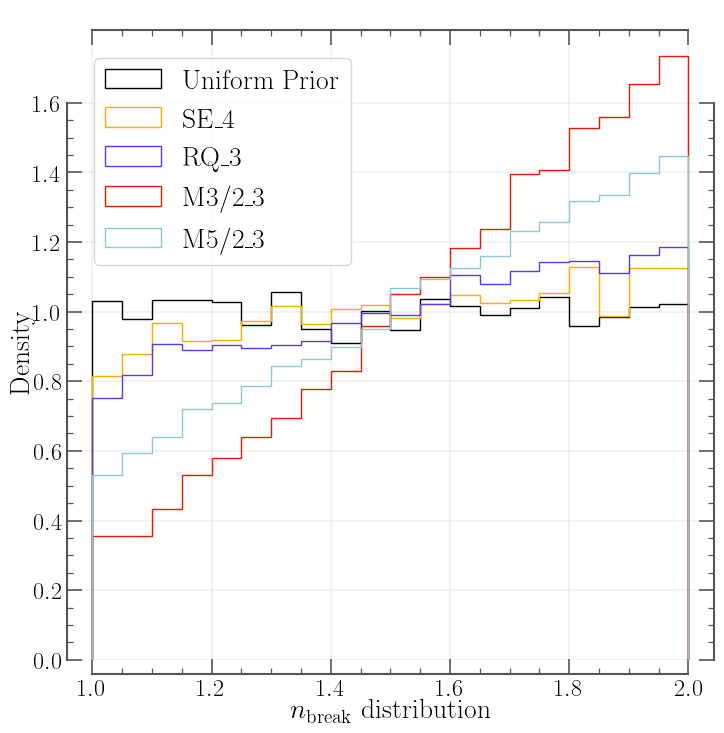

In [ ]:
plt.figure(figsize=(8, 8))
nbreak_plot(["SE_10ns_4", "RQ_10ns_3", "M32_10ns_3", "M52_10ns_3"], cols,
            plot_prior=True, 
            labs=["SE_4", "RQ_3", "M3/2_3", "M5/2_3"],
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.show()

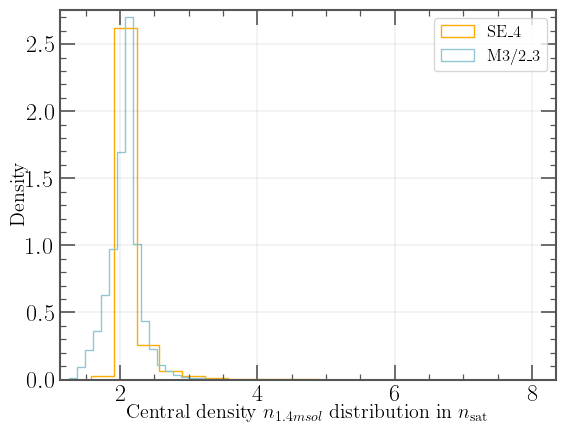

In [74]:
se4_n14m = n_14m(eos_se4, mr_se4, m_target=0.7)
m323_n14m = n_14m(eos_m323, mr_m323, m_target=0.7)

plt.hist(se4_n14m, bins=20, density=True, edgecolor=cols[0],  histtype='stepfilled', fill=False, label='SE_4')
plt.hist(m323_n14m, bins=20, density=True, edgecolor=cols[3], histtype='stepfilled', fill=False, label='M3/2_3')
plt.ylabel("Density")
plt.xlabel("Central density $n_{1.4msol}$ distribution in $n_{\mathrm{sat}}$")
plt.legend()
plt.show()

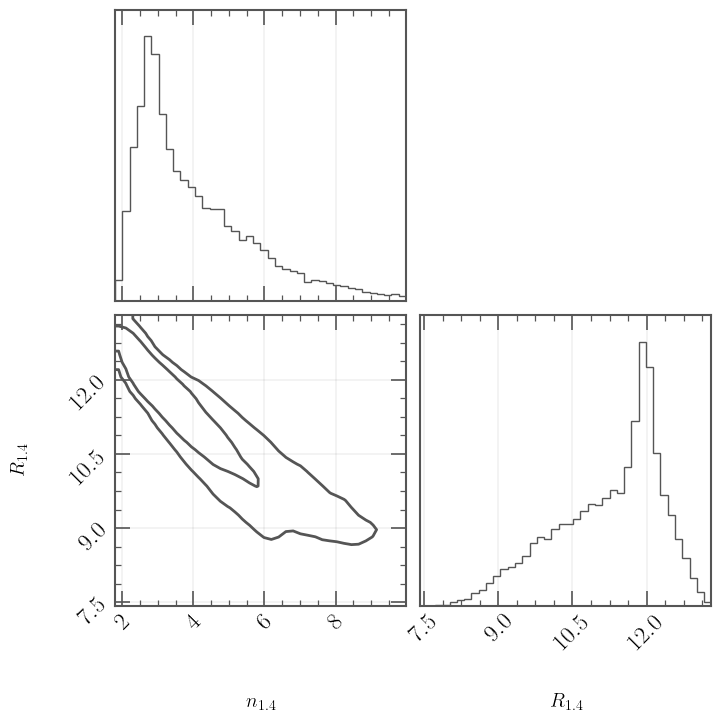

In [11]:
se_n14m = n_14m(eos_se, mr_se)
se_r14 = pa.r_14(mr_se[0, :, :], mr_se[1, :, :])


mask = np.isfinite(se_n14m) & np.isfinite(se_r14)

se_n14m_clean = se_n14m[mask]
se_r14_clean = se_r14[mask]

corner.corner(np.vstack((se_n14m_clean, se_r14_clean)).T, 
              labels=[r"$n_{1.4}$", r"$R_{1.4}$"],
              bins=40,
              smooth=True,
              levels=[0.68, 0.95],
              plot_density=False,
              plot_datapoints=False,
              fig=plt.figure(figsize=(8, 8))
              )
plt.show()

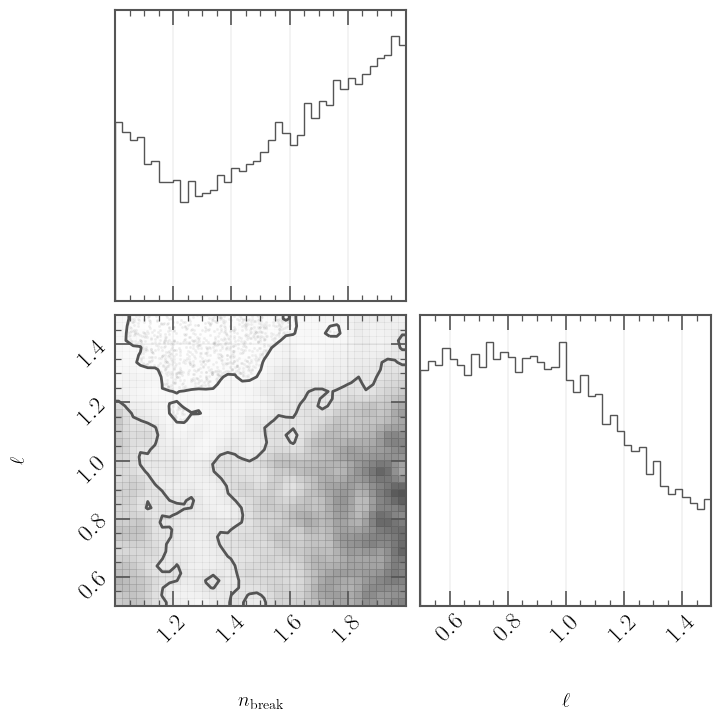

In [21]:
fol = "SE_10ns_1V"
nbreak = np.load(f"/home/sam/thesis/code/results/eos_samples/{fol}/{fol}_nceft_end.npy")
l_hat = np.load(f"/home/sam/thesis/code/results/eos_samples/{fol}/{fol}_lengthscale.npy")

corner.corner(np.vstack((nbreak, l_hat)).T, 
              labels=[r"$n_{\mathrm{break}}$", r"$\ell$"],
              bins=40,
              smooth=True,
              levels=[0.68, 0.95],
              plot_density=True,
              plot_datapoints=True,
              fig=plt.figure(figsize=(8, 8)),
              colors=['#ffac00', '#4e3fee']
              )
plt.show()

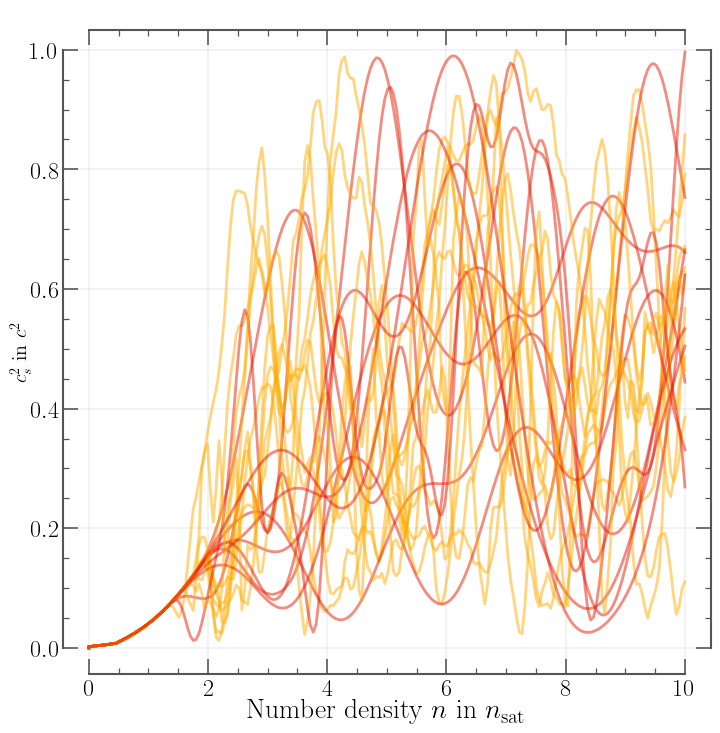

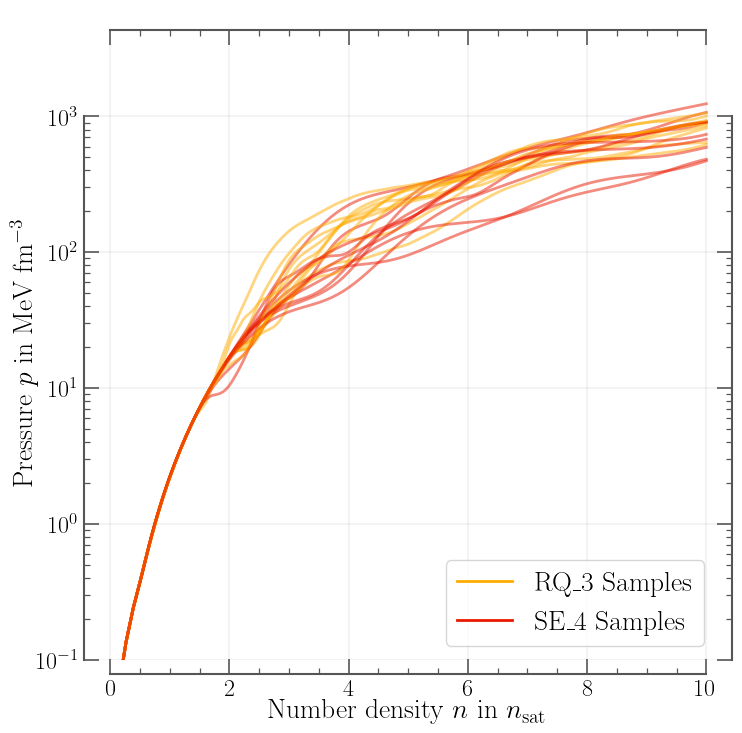

In [ ]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
inds = np.random.choice(range(20000), size=1, replace=False)


ax1.plot([], [], color=cols[0], alpha=1, label='RQ_3 Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='SE_4 Samples')

for i in inds:
    ax1.plot(n, eos_m323[2, i, :], color=cols[0], alpha=0.5, linewidth=2)
    ax1.plot(n, eos_rq3[2, i, :], color=cols[2], alpha=0.5, linewidth=2)

ax1.set_ylabel(r"$c_s^2$ in $c^2$")
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "se_ge_cs2.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color=cols[0], alpha=1, label='RQ_3 Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='SE_4 Samples')

for i in inds:
    ax1.plot(n, eos_m323[1, i, :], color=cols[0], alpha=0.5, linewidth=2)
    ax1.plot(n, eos_rq3[1, i, :], color=cols[2], alpha=0.5, linewidth=2)

ax1.set_ylabel(r"Pressure $p$ in MeV fm$^{-3}$", fontsize=big_fontsize)
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.legend(loc='lower right', fontsize=big_fontsize)
ax1.set_yscale('log')
ax1.set_ylim(0.1,)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "se_ge_p.png", dpi=300)
plt.show()

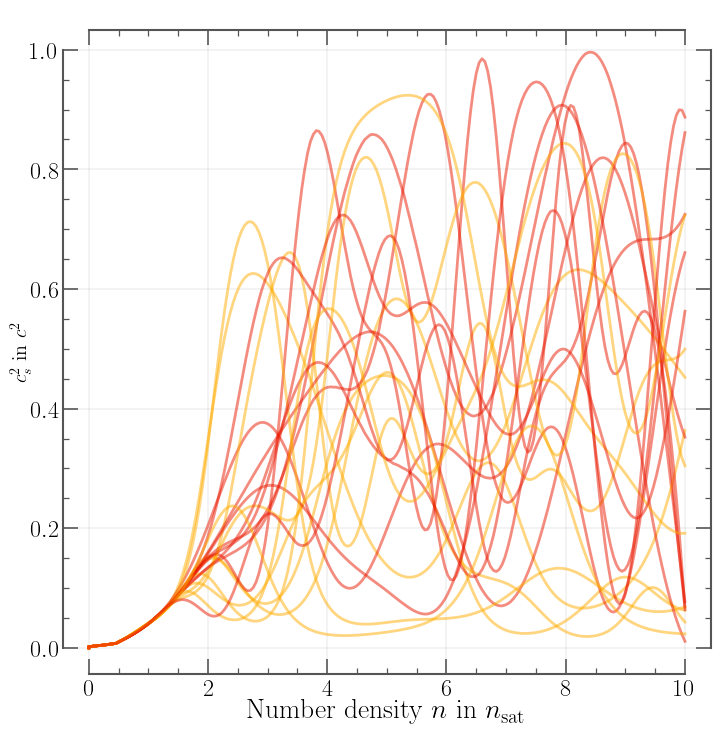

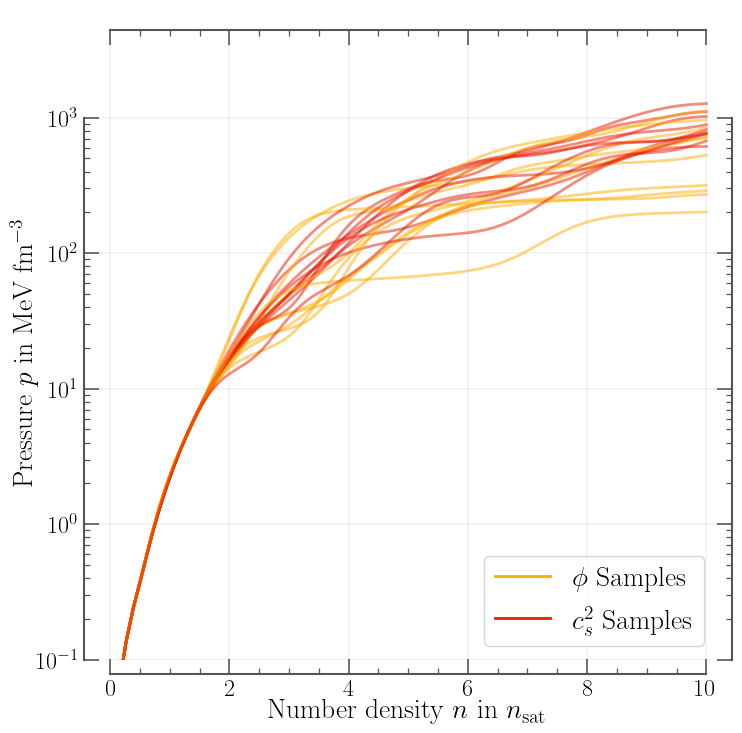

In [ ]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

inds = np.random.choice(range(20000), size=10, replace=False)

ax1.plot([], [], color=cols[0], alpha=1, label='$\phi$ Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='$c_s^2$ Samples')

for i in inds:
    ax1.plot(n, eos_se[2, i, :], color=cols[0], alpha=0.5, linewidth=2)
    ax1.plot(n, eos_se4[2, i, :], color=cols[2], alpha=0.5, linewidth=2)

ax1.set_ylabel(r"$c_s^2$ in $c^2$")
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.set_ylim(top=1.01)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "se_ge_cs2.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))

ax1.plot([], [], color=cols[0], alpha=1, label='$\phi$ Samples')
ax1.plot([], [], color=cols[2], alpha=1, label='$c_s^2$ Samples')

for i in inds:
    ax1.plot(n, eos_se[1, i, :], color=cols[0], alpha=0.5, linewidth=2)
    ax1.plot(n, eos_se4[1, i, :], color=cols[2], alpha=0.5, linewidth=2)

ax1.set_ylabel(r"Pressure $p$ in MeV fm$^{-3}$", fontsize=big_fontsize)
ax1.set_xlabel(r"Number density $n$ in $n_{\mathrm{sat}}$", fontsize=big_fontsize)
ax1.legend(loc='lower right', fontsize=big_fontsize)
ax1.set_yscale('log')
ax1.set_ylim(0.1,)
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "se_ge_p.png", dpi=300)
plt.show()

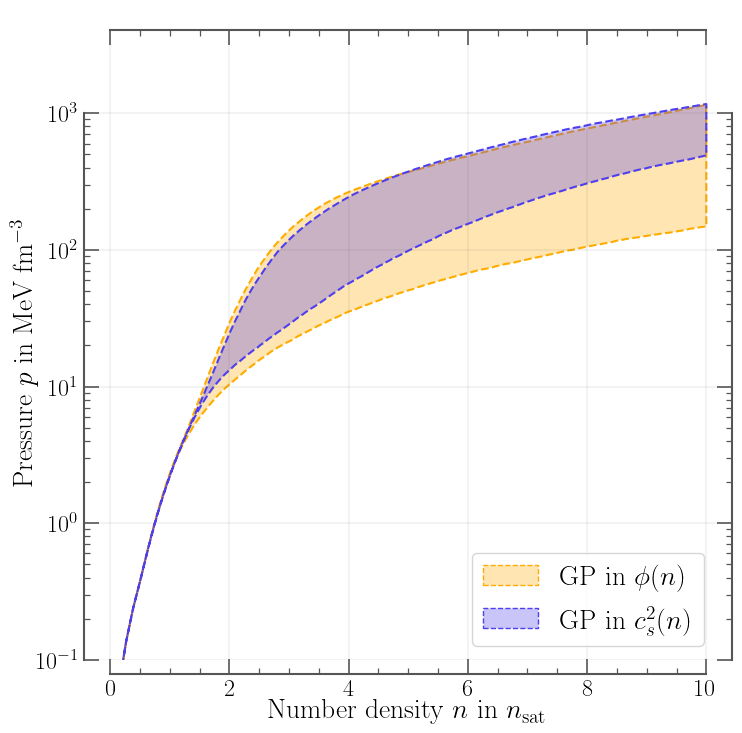

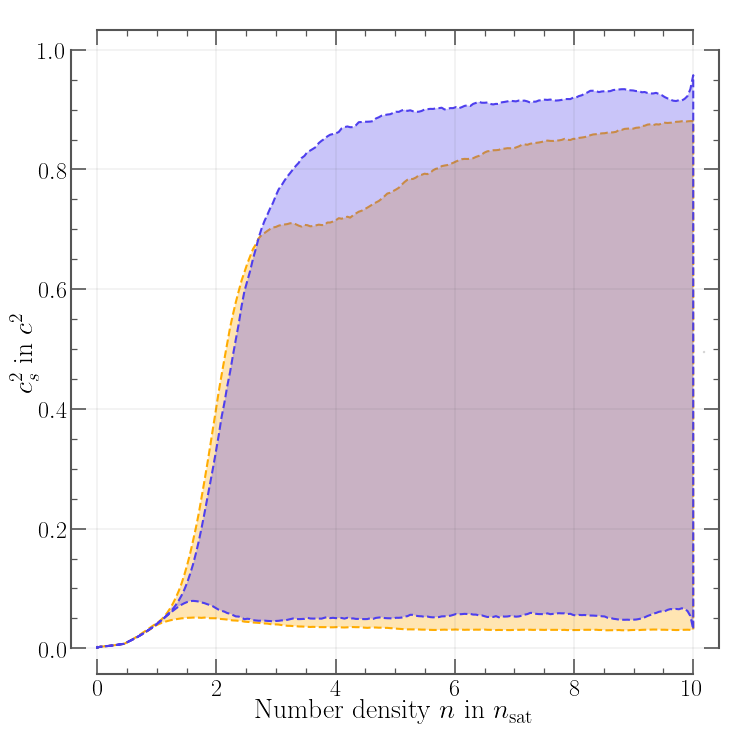

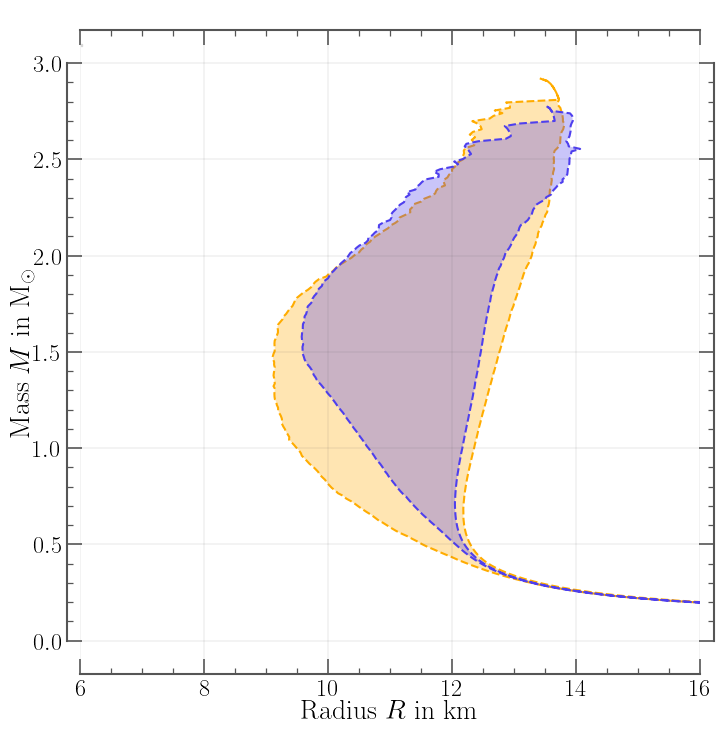

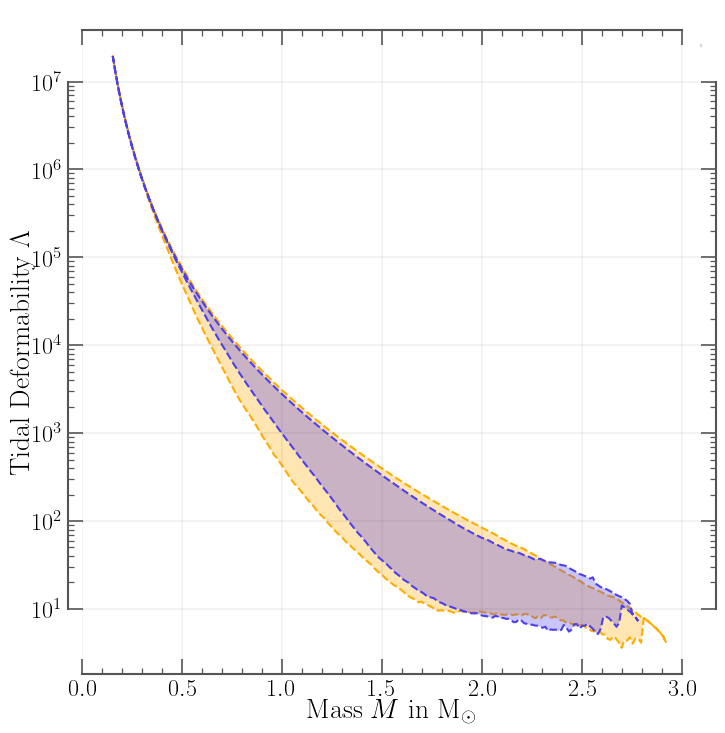

In [77]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_rq, eos_rq3], 
                        ax1, 
                        mr_list=[mr_rq, mr_rq3], 
                        labels=['GP in $\phi(n)$', 'GP in $c_s^2(n)$'], 
                        colours=cols,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "limiting_rq_p_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_rq, eos_rq3], ax1=None, ax2=ax1, 
                        mr_list=[mr_rq, mr_rq3], 
                        labels=['GP in \phi(n)', 'GP in c_s^2(n)'], 
                        colours=cols, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "limiting_rq_cs2_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_rq, eos_rq3], ax1=None, ax3=ax1, 
                        mr_list=[mr_rq, mr_rq3], 
                        labels=['GP in \phi(n)', 'GP in c_s^2(n)'], 
                        colours=cols, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "limiting_rq_mr_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_rq, eos_rq3], ax1=None, ax4=ax1, 
                        mr_list=[mr_rq, mr_rq3], 
                        labels=['GP in \phi(n)', 'GP in c_s^2(n)'], 
                        colours=cols, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.xlim(0, 3.1)
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "limiting_rq_tide_prior.png", dpi=300)
plt.show()

In [75]:
def cs2_6ns(eos: np.array, 
          n: np.array= None, cs2_target: float=6.0) -> np.array:
    """
    Parameters
    ----------
    eos : np.array
        Array of EoS samples, shape (N_samples, 3, N_points), where the second dimension corresponds to (energy density, pressure, sound speed squared).
    n : np.array, optional
        Number density array corresponding to the EoS samples. If not provided, defaults to a range of [0,10] n_sat with 275 points.

    Returns 
    ----------
    np.array
        pressures [MeV/fm^3] at 3 times nuclear saturation density for each EoS sample. 
    """
    if n is None:
        n = anal.get_n_test(10, 200)

    cs2 = eos[2]


    cs2_6 = np.array([np.interp(cs2_target, n, cs) for cs in cs2])

    return cs2_6

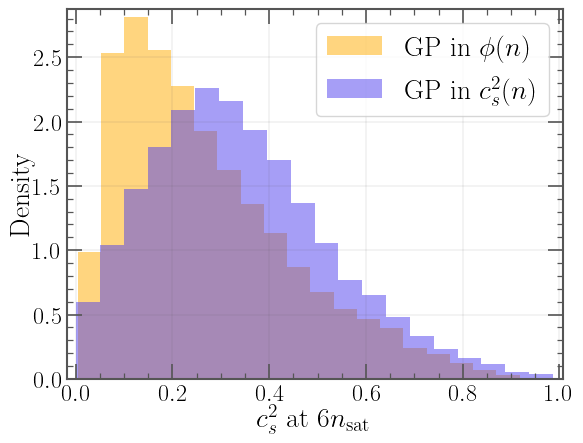

In [66]:
labs = ["GP in $\phi(n)$", "GP in $c_s^2(n)$"]
for i, (eos_i) in enumerate([eos_rq, eos_rq3]):
                data_0 = cs2_6ns(eos_i)

                plt.hist(data_0, bins=20, density=True, label=labs[i], alpha=0.5, color=cols[i]) # the linestyle is the only element not repeated

plt.legend(fontsize=big_fontsize)
plt.xlabel(r"$c_s^2$ at $6 n_{\mathrm{sat}}$", fontsize=big_fontsize)
plt.ylabel("Density", fontsize=big_fontsize)
plt.show()

# different $\ell$

## se

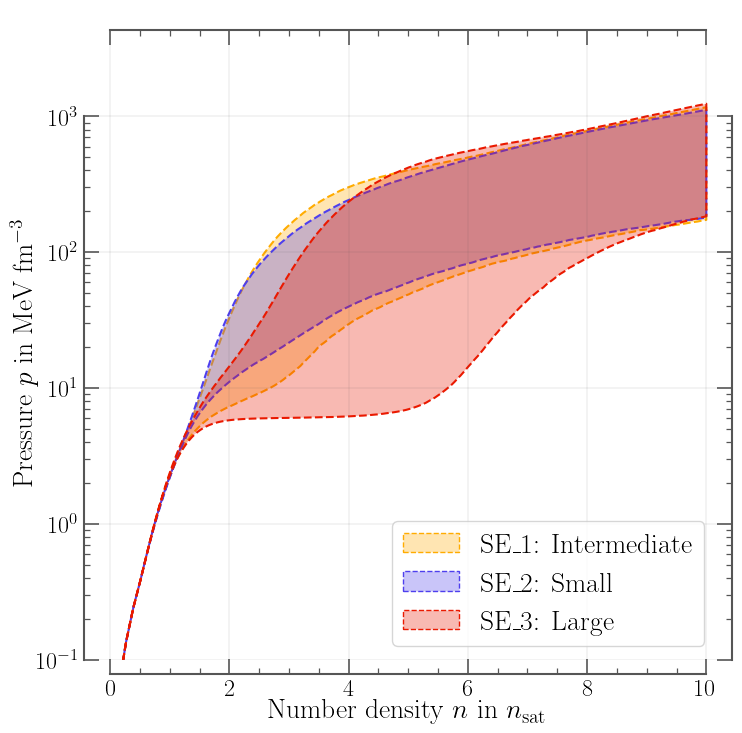

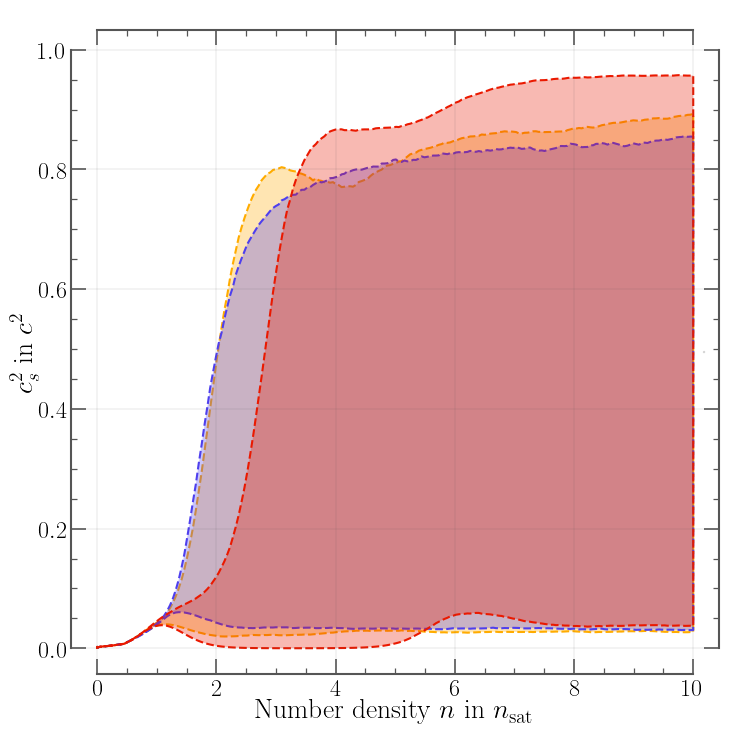

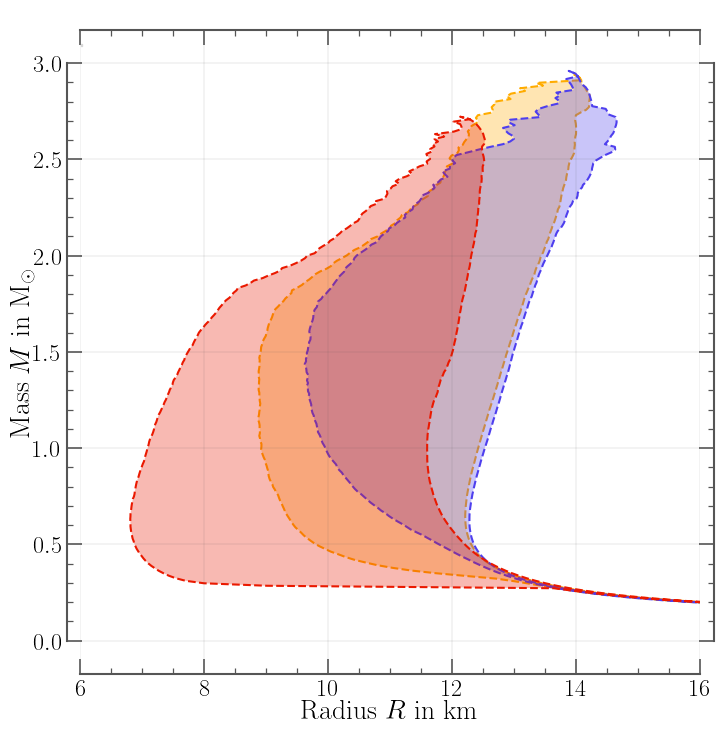

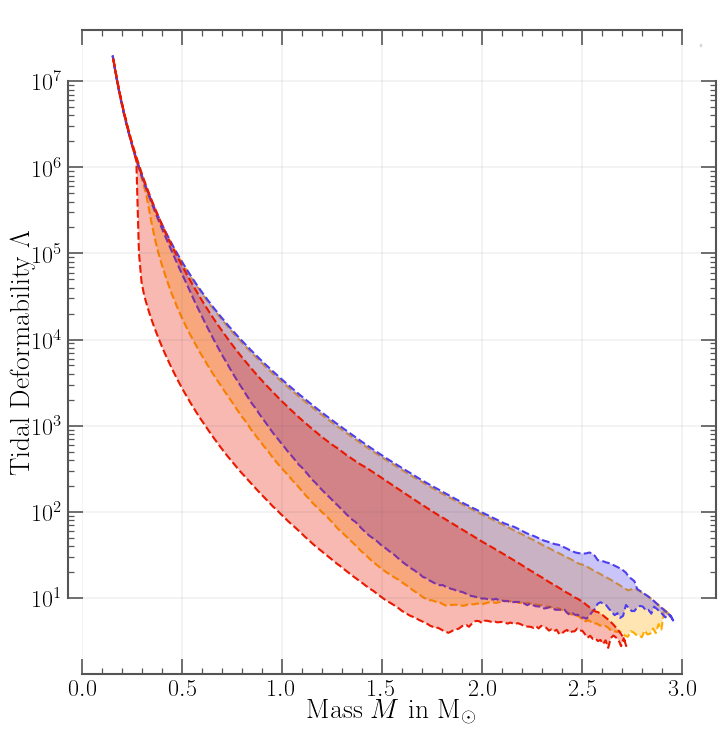

In [13]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se2, eos_se3], 
                        ax1, 
                        mr_list=[mr_se, mr_se2, mr_se3], 
                        labels=['SE_1: Intermediate', 'SE_2: Small', 'SE_3: Large'], 
                        colours=cols,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_se_p_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se2, eos_se3], ax1=None, ax2=ax1, 
                        mr_list=[mr_se, mr_se2, mr_se3], 
                        colours=cols, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_se_cs2_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se2, eos_se3], ax1=None, ax3=ax1, 
                        mr_list=[mr_se, mr_se2, mr_se3], 
                        colours=cols, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_se_mr_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se, eos_se2, eos_se3], ax1=None, ax4=ax1, 
                        mr_list=[mr_se, mr_se2, mr_se3], 
                        colours=cols, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.xlim(0, 3.1)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_se_tide_prior.png", dpi=300)
plt.show()

<Figure size 800x800 with 0 Axes>

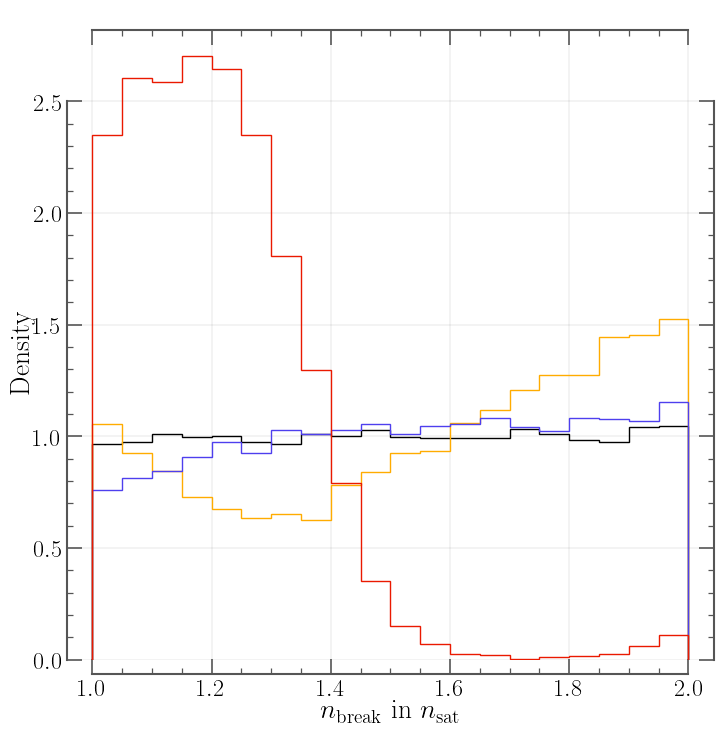

In [14]:
plt.figure(figsize=(8, 8))
nbreak_plot(["SE_10ns_1", "SE_10ns_2", "SE_10ns_3"], cols,
            plot_prior=True, 
            labs=["SE_1", "SE_2", "SE_3"],
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.show()

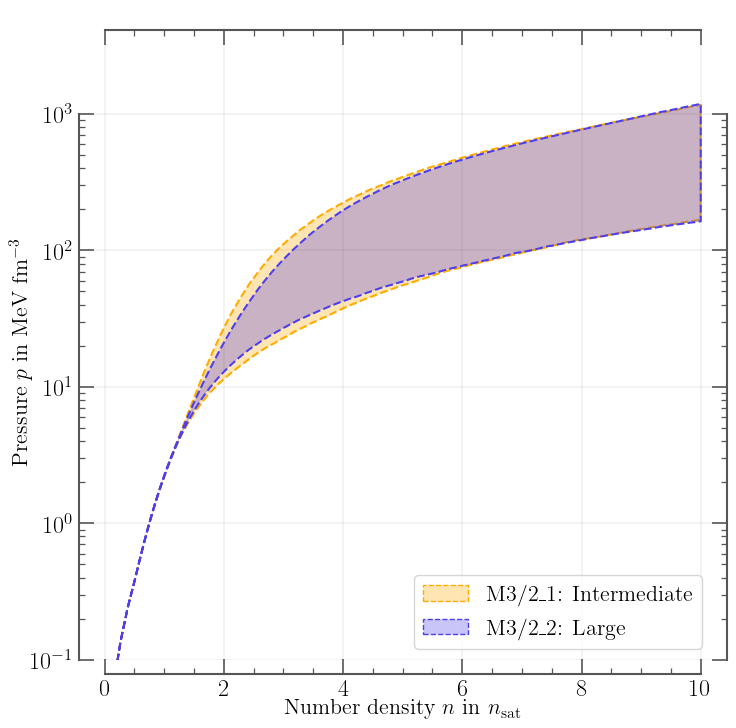

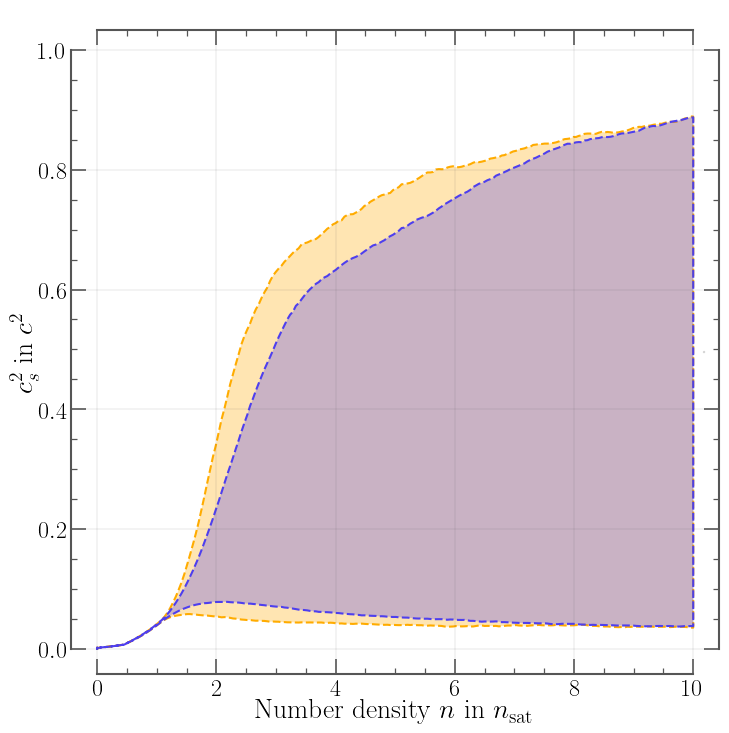

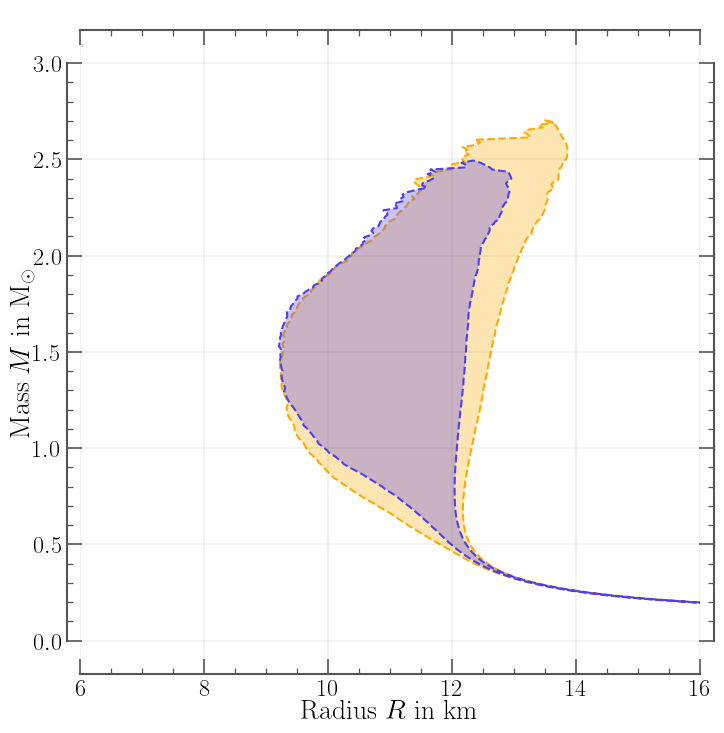

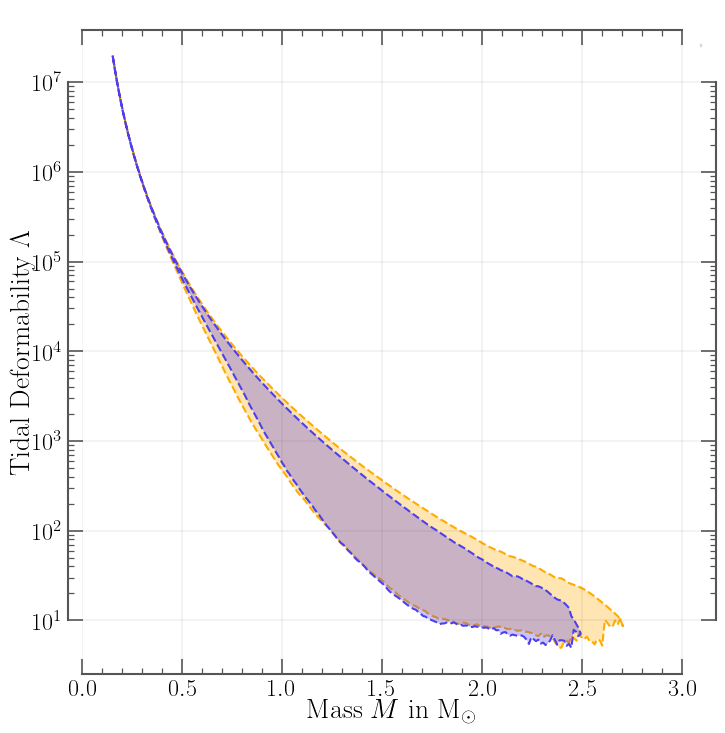

In [ ]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_m32, eos_m322], 
                        ax1, 
                        mr_list=[mr_m32, mr_m322], 
                        labels=['M3/2_1: Intermediate', 'M3/2_2: Large'], 
                        colours=cols,
                        plot_mean=False, axis_fontsize=solo_fontsize, legend_fontsize=solo_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_m32_p_prior.png", dpi=300)
plt.show()

## different kernel, large $\ell$

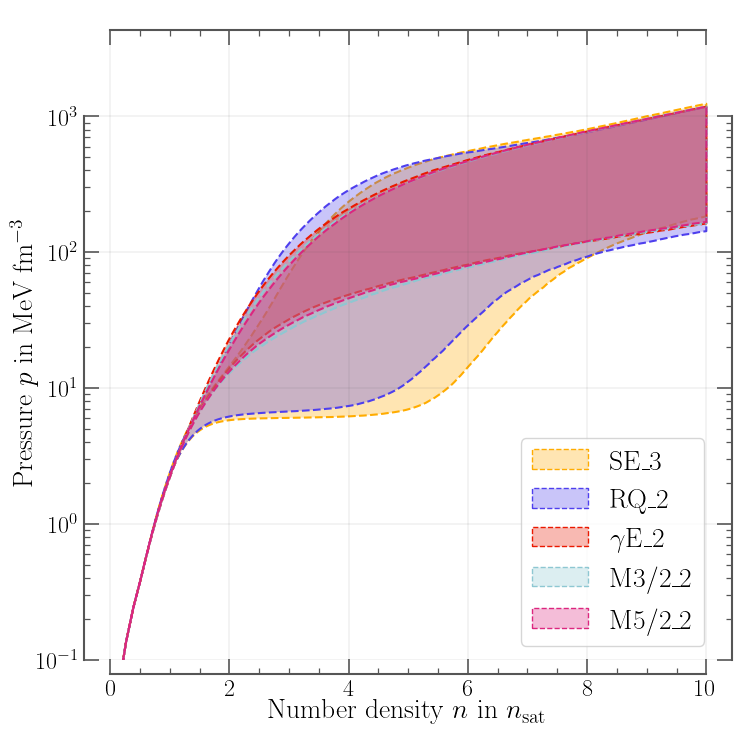

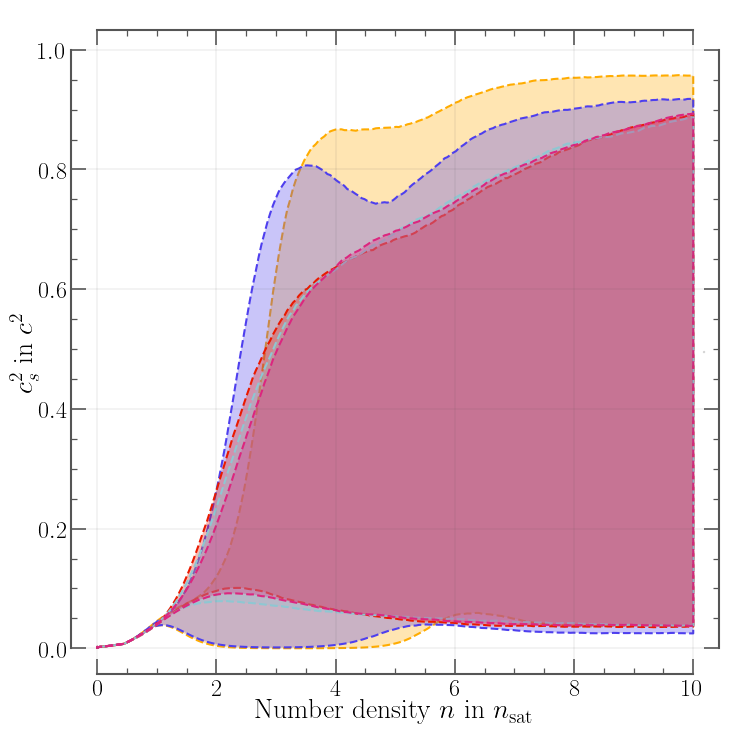

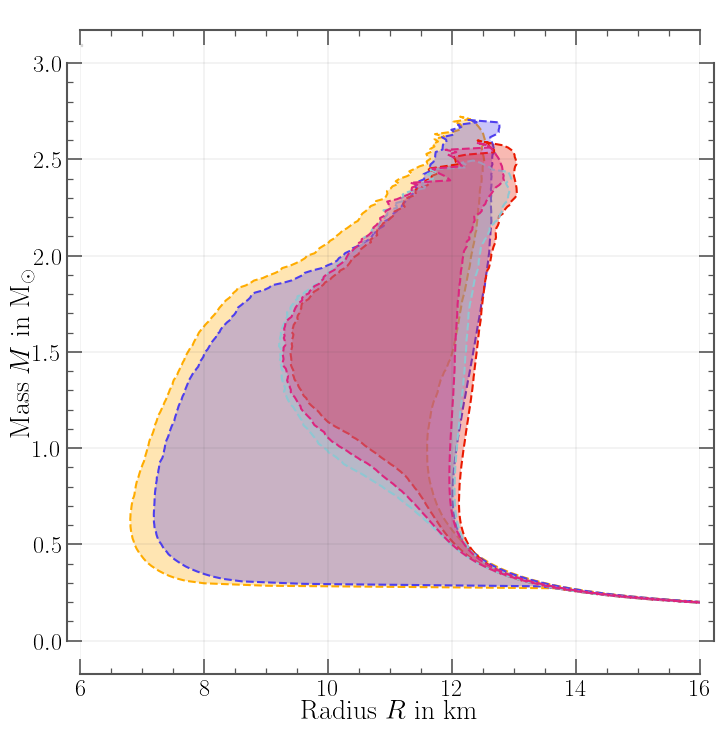

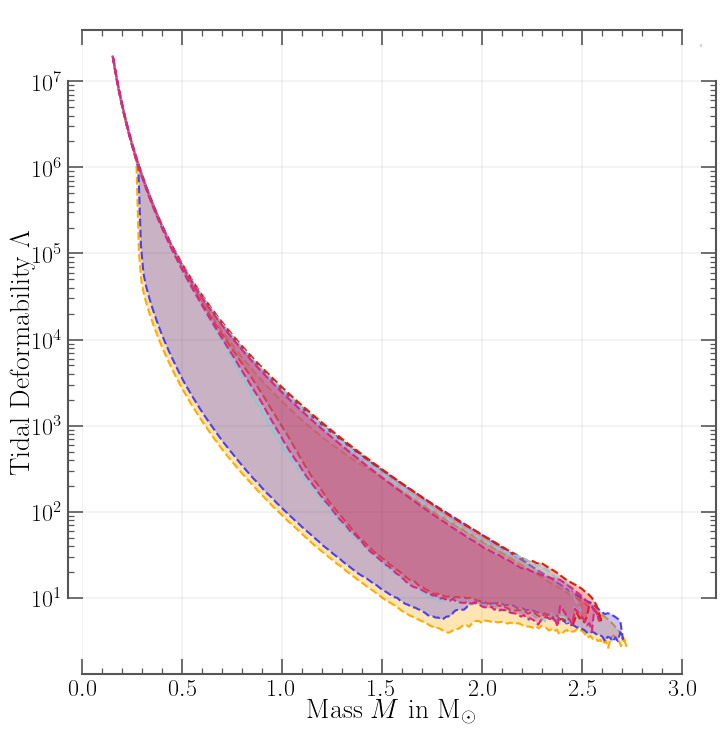

In [5]:
fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se3, eos_rq2, eos_ge2, eos_m322, eos_m522], 
                        ax1, 
                        mr_list=[mr_se3, mr_rq2, mr_ge2, mr_m322, mr_m522], 
                        labels=['SE_3', 'RQ_2', '$\gamma$E_2', 'M3/2_2', 'M5/2_2'],
                        colours=cols,
                        plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(0.1,)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernel_large_p_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se3, eos_rq2, eos_ge2, eos_m322, eos_m522], ax1=None, ax2=ax1, 
                        mr_list=[mr_se3, mr_rq2, mr_ge2, mr_m322, mr_m522], 
                        colours=cols, plot_alone="cs2", legend_fontsize = 0, axis_fontsize=big_fontsize, plot_mean=False, plot_samples=False)
ax1.set_title(" ")
ax1.set_ylim(top=1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernel_large_cs2_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se3, eos_rq2, eos_ge2, eos_m322, eos_m522], ax1=None, ax3=ax1, 
                        mr_list=[mr_se3, mr_rq2, mr_ge2, mr_m322, mr_m522], 
                        colours=cols, plot_alone="mr", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernel_large_mr_prior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8,8))
pa.plot_eos_comparisons([eos_se3, eos_rq2, eos_ge2, eos_m322, eos_m522], ax1=None, ax4=ax1, 
                        mr_list=[mr_se3, mr_rq2, mr_ge2, mr_m322, mr_m522], 
                        colours=cols, plot_alone="tide", legend_fontsize = 0, axis_fontsize=big_fontsize)
ax1.set_title(" ")
plt.xlim(0, 3.1)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernel_large_tide_prior.png", dpi=300)
plt.show()

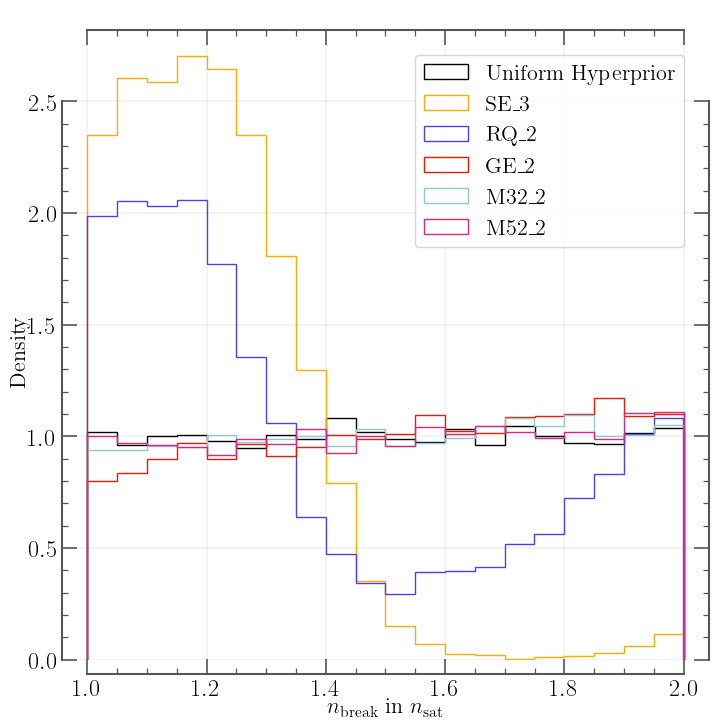

In [16]:
plt.figure(figsize=(8, 8))
nbreak_plot(["SE_10ns_3", "RQ_10ns_2", "GE_10ns_2", "M32_10ns_2", "M52_10ns_2"], cols,
            plot_prior=True, 
            labs=["SE_3", "RQ_2", "GE_2", "M32_2", "M52_2"],
            legend_fontsize=big_fontsize, axis_fontsize=solo_fontsize)
plt.title(" ")
plt.legend(fontsize=solo_fontsize)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernel_large_nbreak_prior.png", dpi=300)
plt.show()